# Estimation Risk in Mean Variance Portfolios

Muhammad Ali Rashid

This notebook asks one question. How much of a mean variance portfolio is signal, and how much is estimation error?

The investable universe is the 11 SPDR sector ETFs from June 2018 to September 4, 2026. SPY never gets a weight. It serves as the market factor in the CAPM and as a passive benchmark. Put SPY in the universe and you hand the optimizer an asset that is almost an exact combination of the other eleven. It will lever that near duplicate into an arbitrage that doesn't exist.

I use simple returns throughout and never switch. Section 1.2 explains why.

Every moment that reaches an optimizer is annualized. Mean times 252, covariance times 252, volatility times √252. Every Sharpe ratio is annual. That keeps γ readable on the usual 1 to 10 scale.

To run it, restart the kernel and Run All. The price panel ships with the repo in `data/prices.csv` and ends on September 4, 2026. `END_DATE` pins that date, so every rerun reproduces the numbers you read here. Set `END_DATE = None` and the loader pulls fresh data from Yahoo Finance. The code still runs, but the prose describes the frozen panel, so the numbers in the text will no longer match.

## Section 0. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.optimize import minimize

SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.titlesize": 12, "axes.labelsize": 10, "legend.fontsize": 9,
})

SECTORS = ["XLC", "XLY", "XLP", "XLE", "XLF", "XLV", "XLI", "XLB", "XLRE", "XLK", "XLU"]
MARKET  = "SPY"
ASSETS  = SECTORS              # investable universe: the 11 sectors only
TICKERS = SECTORS + [MARKET]   # everything downloaded; SPY is the CAPM factor and a benchmark

START_DATE = "2018-06-18"
END_DATE   = "2026-09-04"      # frozen panel; set to None to run through the latest close

CACHE_DIR  = Path("data")
CACHE_PATH = CACHE_DIR / "prices.csv"

TRADING_DAYS      = 252
RETURN_CONVENTION = "simple"
RISK_FREE_ANNUAL  = 0.0
GAMMA             = 3.0
K                 = len(ASSETS)

print(f"{K} investable sectors, {MARKET} as factor and benchmark | "
      f"{START_DATE} to {END_DATE} | seed {SEED} | gamma {GAMMA}")

11 investable sectors, SPY as factor and benchmark | 2018-06-18 to 2026-09-04 | seed 42 | gamma 3.0


## Section 1. Data Pipeline

### 1.1 Design

Three functions, each with one job.

`_download_prices` is the only code in the notebook that touches the network. Keeping it isolated means you can reason about the cache, and test it, without a connection. `load_prices` owns the cache and decides whether the file on disk is good enough. `to_returns` turns prices into returns.

I download with `auto_adjust=True`, which returns closes adjusted for splits and dividends. This matters. An unadjusted series books a fake one day loss on every dividend date. All twelve of these ETFs pay dividends, so raw closes would drag down every mean and distort every covariance in the notebook.

Adjusted prices come with a catch. Yahoo rewrites the whole adjusted history every time a fund pays a new dividend. Download the same window twice, a month apart, and you get slightly different prices all the way back to 2018. That is why the panel is frozen at `END_DATE` and committed to the repo. Without the freeze, nothing here would reproduce.

Every path is relative and built with `pathlib`. Clone the repo without a data folder and you get a clean download, not a `FileNotFoundError`.

In [2]:
def _latest_expected_trading_day(asof=None):
    """Most recent weekday whose US session should have closed by now.

    Conservative on purpose: before 5pm New York it falls back to the previous day, so
    running the notebook mid session does not count today as missing data and trigger a
    pointless download. Weekends roll back to Friday. Exchange holidays are not handled.
    """
    ts = pd.Timestamp.today(tz="America/New_York") if asof is None else pd.Timestamp(asof)
    if ts.tz is None:
        ts = ts.tz_localize("America/New_York")
    if ts.hour < 17:
        ts = ts - pd.Timedelta(days=1)
    day = ts.normalize().tz_localize(None)
    while day.weekday() >= 5:                 # 5 = Sat, 6 = Sun
        day = day - pd.Timedelta(days=1)
    return day


def _download_prices(tickers, start, end=None):
    """Fetch adjusted daily closes from Yahoo Finance. The only networked call."""
    import yfinance as yf
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True,
                      progress=False, threads=True)
    px = raw["Close"] if isinstance(raw.columns, pd.MultiIndex) else raw[["Close"]]
    px = px.reindex(columns=tickers)
    px.index = pd.to_datetime(px.index).tz_localize(None)
    px.index.name = "Date"
    return px.sort_index()


def load_prices(tickers=TICKERS, start=START_DATE, end=END_DATE, cache_path=CACHE_PATH,
                force_refresh=False, verbose=True, _downloader=None):
    """Adjusted closes, read from disk whenever the cache covers the requested window.

    With `end` set the panel is frozen. The cache only has to reach `end`, and the result
    is sliced to `end`, so every rerun sees identical data even after Yahoo back adjusts
    history for a new dividend. With end=None the target is the latest completed session.

    The cache is usable only if all three hold:
      1. every requested ticker is a column,
      2. the stored history reaches back to `start`,
      3. the last stored date is at or after the target day.

    Fail (1) or (2) and the universe or window changed, so re download in full.
    Fail only (3) and we hold a valid prefix, so download just the tail and splice.

    CSV rather than parquet: parquet needs pyarrow or fastparquet as an extra dependency,
    and at roughly 2,000 rows by 12 columns its advantages are irrelevant.
    """
    downloader = _downloader or _download_prices
    cache_path = Path(cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    target_day = pd.Timestamp(end) if end is not None else _latest_expected_trading_day()
    dl_end = ((target_day + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
              if end is not None else None)          # yfinance treats `end` as exclusive

    cached = None
    if cache_path.exists() and not force_refresh:
        cached = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        cached.index = pd.to_datetime(cached.index)
        have_all     = set(tickers).issubset(cached.columns)
        covers_start = cached.index.min() <= pd.Timestamp(start) + pd.Timedelta(days=7)
        is_current   = cached.index.max() >= target_day
        if have_all and covers_start and is_current:
            out = cached.loc[:target_day].reindex(columns=tickers)
            if verbose:
                print(f"CACHE HIT  {cache_path}  {out.index.min().date()} -> "
                      f"{out.index.max().date()}  (no network call)")
            return out
        if verbose:
            print(f"CACHE STALE  tickers={have_all}  start={covers_start}  "
                  f"reaches {target_day.date()}={is_current}")

    can_extend = (cached is not None
                  and set(tickers).issubset(cached.columns)
                  and cached.index.min() <= pd.Timestamp(start) + pd.Timedelta(days=7))

    if can_extend:
        gap_start = (cached.index.max() - pd.Timedelta(days=5)).strftime("%Y-%m-%d")
        if verbose:
            print(f"  -> incremental download from {gap_start}")
        new = downloader(tickers, gap_start, dl_end)
        px  = pd.concat([cached.reindex(columns=tickers), new]).sort_index()
        px  = px[~px.index.duplicated(keep="last")]      # overlap: newest row wins
    else:
        if verbose:
            print(f"  -> full download from {start}")
        px = downloader(tickers, start, dl_end)

    px.to_csv(cache_path)
    px = px.loc[:target_day]
    if verbose:
        print(f"WROTE  {cache_path}  {px.index.min().date()} -> {px.index.max().date()}  "
              f"{px.shape[0]} rows x {px.shape[1]} cols")
    return px


def to_returns(prices, convention=RETURN_CONVENTION):
    """Prices -> daily returns, dropping any date with a missing observation."""
    if convention == "log":
        rets = np.log(prices).diff()
    elif convention == "simple":
        rets = prices.pct_change()
    else:
        raise ValueError("convention must be 'simple' or 'log'")
    return rets.dropna(how="any")

In [3]:
prices = load_prices()
rets   = to_returns(prices)

print(f"\nprices : {prices.shape[0]} rows x {prices.shape[1]} cols, "
      f"{prices.index.min().date()} -> {prices.index.max().date()}")
print(f"returns: {rets.shape[0]} rows x {rets.shape[1]} cols, "
      f"{rets.index.min().date()} -> {rets.index.max().date()}")
print(f"missing values remaining: {int(rets.isna().sum().sum())}")
rets.tail(3)

CACHE HIT  data/prices.csv  2018-06-18 -> 2026-09-04  (no network call)

prices : 2066 rows x 12 cols, 2018-06-18 -> 2026-09-04
returns: 2064 rows x 12 cols, 2018-06-20 -> 2026-09-04
missing values remaining: 0


,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU,SPY
Date,,,,,,,,,,,,
2026-09-02,0.013889,0.002356,0.003284,0.005095,0.008042,0.007456,0.000289,0.016900,-0.007039,-0.000218,0.002585,0.006931
2026-09-03,0.008539,0.013930,-0.003157,-0.007373,0.015609,0.001792,0.010302,-0.006232,0.011891,0.012908,0.008437,0.007965
2026-09-04,-0.011907,-0.013309,-0.007976,-0.008666,-0.007855,-0.010447,0.004067,-0.003421,-0.007232,0.007044,0.001162,-0.001381


In [4]:
_ = load_prices()

CACHE HIT  data/prices.csv  2018-06-18 -> 2026-09-04  (no network call)


In [5]:
summary = pd.DataFrame({
    "ann. mean (%)": rets.mean() * TRADING_DAYS * 100,
    "ann. vol (%)":  rets.std(ddof=1) * np.sqrt(TRADING_DAYS) * 100,
    "ann. Sharpe":   (rets.mean() * TRADING_DAYS) / (rets.std(ddof=1) * np.sqrt(TRADING_DAYS)),
    "skew":          rets.skew(),
    "excess kurt.":  rets.kurt(),
}).round(3)
print("Full sample descriptive statistics (annualized where noted)")
summary

Full sample descriptive statistics (annualized where noted)


,ann. mean (%),ann. vol (%),ann. Sharpe,skew,excess kurt.
XLC,13.270,22.124,0.600,-0.291,6.725
XLY,12.590,23.891,0.527,-0.313,6.993
XLP,10.011,15.635,0.640,-0.178,14.121
XLE,15.901,31.688,0.502,-0.486,12.817
XLF,13.752,23.198,0.593,-0.200,15.101
XLV,11.784,17.466,0.675,-0.149,9.209
XLI,14.561,21.313,0.683,-0.195,12.526
XLB,11.512,21.934,0.525,-0.162,9.108
XLRE,9.753,21.756,0.448,-0.678,14.702
XLK,24.740,26.781,0.924,-0.019,7.614


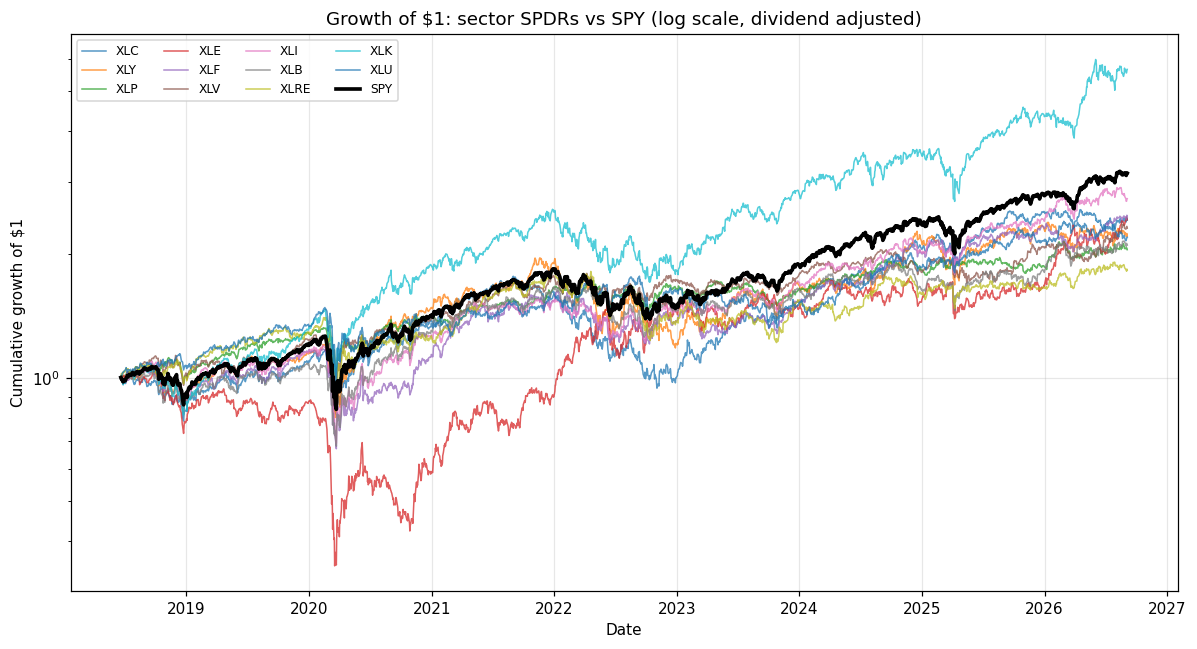

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))
growth = (1 + rets).cumprod()
for t in SECTORS:
    ax.plot(growth.index, growth[t], lw=1.0, alpha=0.75, label=t)
ax.plot(growth.index, growth[MARKET], lw=2.4, color="black", label=MARKET)
ax.set_yscale("log")
ax.set_title("Growth of $1: sector SPDRs vs SPY (log scale, dividend adjusted)")
ax.set_xlabel("Date"); ax.set_ylabel("Cumulative growth of $1")
ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

### 1.2 Return convention

I use simple returns everywhere, today's close over yesterday's close, minus one.

One argument settles it. Portfolio return is a weighted average of asset returns only under the simple convention. The identity rₚ = wᵀr holds exactly for simple returns and only approximately for log returns, because the log of a weighted sum is not the weighted sum of logs. Sections 3, 4 and 5 all build portfolio returns from a weight vector. Log returns would bake an approximation into the one object this whole analysis is about. Mean variance theory is stated on simple returns too.

The cost is that simple returns don't add across time. So all compounding here uses `(1 + r).cumprod()` and never `cumsum()`.

The panel runs from June 18, 2018 to September 4, 2026. That start date isn't arbitrary. XLC started trading on June 18, 2018, and since I drop any date with a missing value, XLC is the binding constraint. Start earlier and you only create rows that get dropped. The result is 2,066 price rows and 2,064 daily returns with zero missing values.

Two things in the descriptive table matter later, so I'll flag them now. First, excess kurtosis runs from 6.7 to 15.4 across the twelve series, and ten of the eleven sectors are negatively skewed, with XLU the lone exception. These are not normal returns. Section 2.1 simulates from a normal anyway, so the estimation error I measure there is a floor. Real data does worse. Second, XLK dominates the table with a 24.7% annualized mean and a 0.924 Sharpe. Remember that number. The optimizer finds it every time.

### 1.3 Cache logic

`load_prices` reads `data/prices.csv` and accepts it only when three checks pass. Every requested ticker has a column. The stored history reaches back to `START_DATE`, with a one week tolerance because the start can land on a weekend. And the last stored date reaches the target day, which is `END_DATE` when the panel is frozen and the latest completed session otherwise. For the live case I use a 5pm New York cutoff, so running the notebook mid session doesn't flag today as missing.

Pass all three and no network call happens. Fail the first or second and the request is for a different universe or window, so I download everything again. Fail only the third and the file on disk is a valid prefix, so I pull from five days before the last stored date and splice, letting the newer row win wherever the two overlap.

I accept two limitations on purpose. I don't use an exchange holiday calendar, so on a market holiday the live mode makes one redundant download. The fix is another dependency, and a few wasted seconds cost less. The cache is also keyed by filename, not by universe, so changing `TICKERS` forces a full download instead of quietly mixing two panels. That is the safe way to fail.

The cache is CSV, not parquet. Parquet needs pyarrow or fastparquet, one more thing to install, and at 2,066 rows by 12 columns its speed and compression buy you nothing.

`force_refresh=True` skips all of it.

## Section 2. Parameter and Model Uncertainty

### 2.1 Simulation study with no model risk

This setup removes model risk on purpose. I declare the full sample estimates to be the truth, μ⋆ and Σ⋆, draw iid samples from N(μ⋆, Σ⋆), and ask how close the sample moments get. Whatever error shows up is a floor. It is pure estimation error under a perfect model, with iid data, no fat tails and no regime shifts. None of that holds for the returns plotted above.

I track four diagnostics because each answers a different question. RMSE of μ̂ tells you how far off a single expected return is. Relative Frobenius error on Σ̂ tells you how far off the whole covariance matrix is. The distribution of the error in μ̂ for individual sectors shows its shape, not just its size. And the distribution of the estimated Sharpe ratio of a fixed equal weight portfolio is the number a PM actually sees on a page.

In [7]:
MU_STAR    = rets[ASSETS].mean().to_numpy() * TRADING_DAYS
SIGMA_STAR = rets[ASSETS].cov(ddof=1).to_numpy() * TRADING_DAYS

# Simulate in DAILY units (the frequency the data actually arrives at),
# then annualize the resulting estimates so everything is comparable.
mu_star_d    = MU_STAR / TRADING_DAYS
Sigma_star_d = SIGMA_STAR / TRADING_DAYS
L_star = np.linalg.cholesky(Sigma_star_d)

N_GRID  = [63, 126, 252, 504, 1008, 2520]
N_SIMS  = 500

w_eq = np.ones(K) / K
true_sharpe_eq = (w_eq @ MU_STAR) / np.sqrt(w_eq @ SIGMA_STAR @ w_eq)

sim_rng = np.random.default_rng(SEED)
records, mu_err_draws, sharpe_draws = [], {}, {}

for n in N_GRID:
    mu_err = np.empty((N_SIMS, K))
    frob   = np.empty(N_SIMS)
    shp    = np.empty(N_SIMS)
    for b in range(N_SIMS):
        Z = sim_rng.standard_normal((n, K))
        X = mu_star_d + Z @ L_star.T
        mu_hat    = X.mean(axis=0) * TRADING_DAYS
        Sigma_hat = np.cov(X, rowvar=False, ddof=1) * TRADING_DAYS
        mu_err[b] = mu_hat - MU_STAR
        frob[b]   = (np.linalg.norm(Sigma_hat - SIGMA_STAR, "fro")
                     / np.linalg.norm(SIGMA_STAR, "fro"))
        shp[b]    = (w_eq @ mu_hat) / np.sqrt(w_eq @ Sigma_hat @ w_eq)
    mu_err_draws[n] = mu_err
    sharpe_draws[n] = shp
    records.append({
        "n": n,
        "years": round(n / TRADING_DAYS, 2),
        "RMSE(mu) ann.": np.sqrt((mu_err ** 2).mean()),
        "rel. Frobenius err(Sigma)": frob.mean(),
        "SD of est. Sharpe": shp.std(ddof=1),
    })

sim_table = pd.DataFrame(records).set_index("n")
print(f"True equal weight annualized Sharpe under the ground truth: {true_sharpe_eq:.3f}\n")
sim_table.round(4)

True equal weight annualized Sharpe under the ground truth: 0.755



,years,RMSE(mu) ann.,rel. Frobenius err(Sigma),SD of est. Sharpe
n,,,,
63,0.25,0.4703,0.2147,2.1003
126,0.50,0.3227,0.1494,1.4385
252,1.00,0.2250,0.1064,0.9853
504,2.00,0.1580,0.0754,0.6913
1008,4.00,0.1127,0.0538,0.4829
2520,10.00,0.0721,0.0328,0.3176


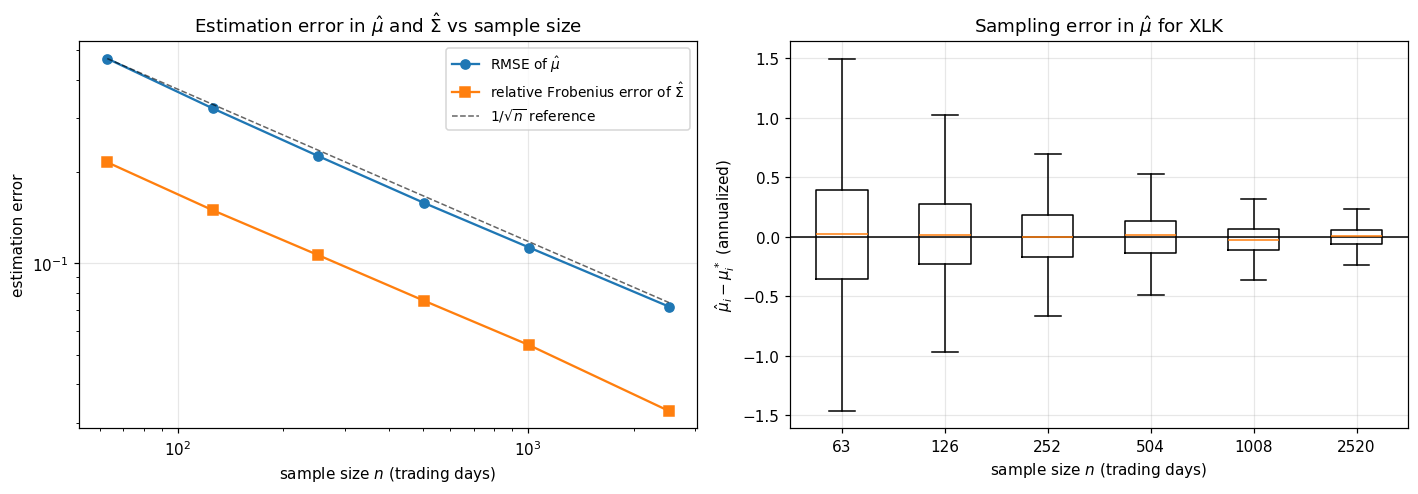

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
ax.loglog(sim_table.index, sim_table["RMSE(mu) ann."], "o-", label=r"RMSE of $\hat{\mu}$")
ax.loglog(sim_table.index, sim_table["rel. Frobenius err(Sigma)"], "s-",
          label=r"relative Frobenius error of $\hat{\Sigma}$")
ref = sim_table["RMSE(mu) ann."].iloc[0] * np.sqrt(sim_table.index[0] / sim_table.index)
ax.loglog(sim_table.index, ref, "k--", lw=1, alpha=0.6, label=r"$1/\sqrt{n}$ reference")
ax.set_xlabel("sample size $n$ (trading days)"); ax.set_ylabel("estimation error")
ax.set_title(r"Estimation error in $\hat{\mu}$ and $\hat{\Sigma}$ vs sample size")
ax.legend()

ax = axes[1]
ax.boxplot([mu_err_draws[n][:, ASSETS.index("XLK")] for n in N_GRID],
           positions=np.arange(1, len(N_GRID) + 1), showfliers=False)
ax.set_xticks(np.arange(1, len(N_GRID) + 1))
ax.set_xticklabels([str(n) for n in N_GRID])
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("sample size $n$ (trading days)")
ax.set_ylabel(r"$\hat{\mu}_i - \mu_i^*$ (annualized)")
ax.set_title(r"Sampling error in $\hat{\mu}$ for XLK")
plt.tight_layout(); plt.show()

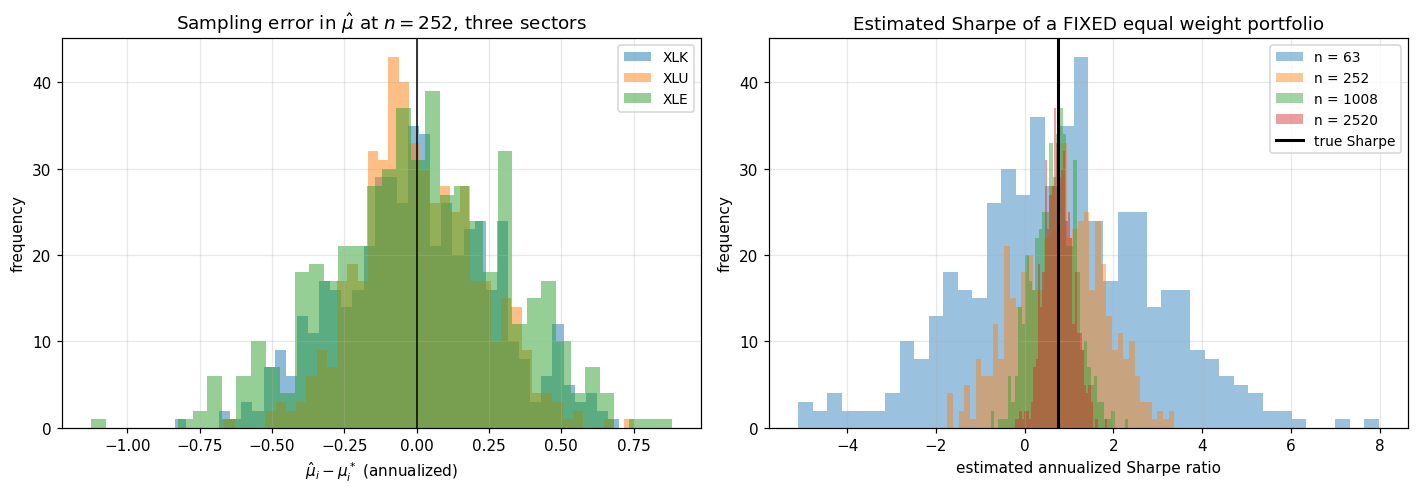

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
for t in ["XLK", "XLU", "XLE"]:
    i = ASSETS.index(t)
    ax.hist(mu_err_draws[252][:, i], bins=40, alpha=0.5, label=f"{t}")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel(r"$\hat{\mu}_i - \mu_i^*$ (annualized)"); ax.set_ylabel("frequency")
ax.set_title(r"Sampling error in $\hat{\mu}$ at $n=252$, three sectors")
ax.legend()

ax = axes[1]
for n in [63, 252, 1008, 2520]:
    ax.hist(sharpe_draws[n], bins=40, alpha=0.45, label=f"n = {n}")
ax.axvline(true_sharpe_eq, color="black", lw=2, label="true Sharpe")
ax.set_xlabel("estimated annualized Sharpe ratio"); ax.set_ylabel("frequency")
ax.set_title("Estimated Sharpe of a FIXED equal weight portfolio")
ax.legend()
plt.tight_layout(); plt.show()

In [10]:
snr = pd.DataFrame({
    "RMSE(mu)/|mu*| mean ratio": [
        np.sqrt((mu_err_draws[n] ** 2).mean()) / np.abs(MU_STAR).mean() for n in N_GRID],
    "rel. Frobenius err(Sigma)": sim_table["rel. Frobenius err(Sigma)"].values,
}, index=N_GRID)
snr.index.name = "n"
print("Estimation error relative to the size of the thing being estimated:")
snr.round(3)

Estimation error relative to the size of the thing being estimated:


,RMSE(mu)/|mu*| mean ratio,rel. Frobenius err(Sigma)
n,,
63,3.459,0.215
126,2.373,0.149
252,1.655,0.106
504,1.162,0.075
1008,0.828,0.054
2520,0.530,0.033


#### Interpretation

Three results. The second one drives most of what follows.

Both errors shrink at the classical 1/√n rate. RMSE on μ̂ falls from 0.4703 at n = 63 to 0.0721 at n = 2,520. That is a factor of 6.5 for 40 times more data, close to √40 ≈ 6.3. Read it plainly. Quadruple your history and you only halve your error. No trick beats that rate for a sample mean.

μ and Σ are nowhere near equally reliable, and the signal to noise table shows it. At n = 252, a full year of daily data, the relative error on Σ̂ is 0.106. The RMSE on μ̂ over the same year is 1.655 times the average size of the true mean. The error is bigger than the thing you are measuring. Even with ten years of data the ratio is 0.530, so a decade of history only gets your error down to half the size of the quantity itself.

That gap is structural. The variance of a sample mean is σ²/n, and for daily equity returns σ dwarfs μ. XLK has a 24.7% annualized mean against 26.8% annualized volatility, so the signal sits under noise of the same size. A sample variance is built from squared deviations of order σ², so its relative error is far smaller. This one fact explains why shrinking μ̂ tames the weights in Section 3.2, and why the strategies that ignore μ hold up in Section 6.

The Sharpe distribution makes it concrete. The true Sharpe of the equal weight portfolio under my ground truth is 0.755. Hold the weights fixed, with zero optimization error, and the Sharpe you estimate from one year of data has a standard deviation of 0.985. From one quarter it is 2.100. A one year backtest Sharpe is a single draw from a distribution wider than the value itself. It is not a measurement.

So "good enough" depends on what you estimate. For Σ, one to two years is defensible. For μ, nothing on this grid is good enough to trust sector by sector. That argues for imposing structure, for shrinkage, or for not estimating μ at all.

### 2.2 Model uncertainty on real data

Two estimators, same data.

Sample moments impose no structure. μ̂ is the sample mean vector and Σ̂ is the sample covariance. That costs 11 parameters for the mean and 66 for the covariance.

The CAPM imposes a single factor. I regress each sector on SPY, rᵢ = αᵢ + βᵢrₘ + εᵢ, then use the law of total expectation and the law of total covariance to get μ̂ᵢ = αᵢ + βᵢμ̂ₘ and Σ̂ = ββᵀσ²ₘ + D, where D holds the residual variances on its diagonal. The covariance now costs 23 parameters instead of 66. Eleven betas, eleven residual variances and one market variance.

That structure is a trade between bias and variance. If one factor is roughly right, you buy a big cut in variance. If it is wrong, you add bias that no amount of data removes.

In [11]:
def capm_moments(returns, sectors=ASSETS, market=MARKET, annualize=True):
    """Single factor (CAPM) estimates of mu and Sigma for the investable sectors."""
    y = returns[sectors].to_numpy()
    x = returns[market].to_numpy()
    X = np.column_stack([np.ones_like(x), x])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    alpha, beta = coef[0], coef[1]
    resid = y - X @ coef
    D = np.diag(resid.var(axis=0, ddof=2))          # ddof=2: intercept + slope
    mu_m, var_m = x.mean(), x.var(ddof=1)

    mu_s  = alpha + beta * mu_m                      # law of total expectation
    Sig_s = np.outer(beta, beta) * var_m + D         # law of total covariance

    s = TRADING_DAYS if annualize else 1.0
    return (pd.Series(mu_s * s, index=sectors),
            pd.DataFrame(Sig_s * s, index=sectors, columns=sectors),
            pd.Series(alpha * TRADING_DAYS, index=sectors),
            pd.Series(beta, index=sectors),
            pd.Series(np.diag(D) * TRADING_DAYS, index=sectors))


MU_SAMPLE    = rets[ASSETS].mean() * TRADING_DAYS
SIGMA_SAMPLE = rets[ASSETS].cov(ddof=1) * TRADING_DAYS
MU_CAPM, SIGMA_CAPM, ALPHA, BETA, IDIO_VAR = capm_moments(rets)

comp = pd.DataFrame({
    "mu sample (%)":     MU_SAMPLE * 100,
    "mu CAPM (%)":       MU_CAPM * 100,
    "difference (pp)":   ((MU_SAMPLE - MU_CAPM) * 100).round(10) + 0.0,   # +0.0 clears negative zeros
    "beta":              BETA,
    "alpha (% ann.)":    ALPHA * 100,
    "idio vol (% ann.)": np.sqrt(IDIO_VAR) * 100,
    "idio share of var": IDIO_VAR / np.diag(SIGMA_SAMPLE),
})
print("Mean vector: sample vs CAPM (annualized)")
comp.round(2)

Mean vector: sample vs CAPM (annualized)


,mu sample (%),mu CAPM (%),difference (pp),beta,alpha (% ann.),idio vol (% ann.),idio share of var
XLC,13.27,13.27,0.0,0.99,-2.40,11.48,0.27
XLY,12.59,12.59,0.0,1.11,-5.07,10.78,0.20
XLP,10.01,10.01,0.0,0.53,1.66,11.95,0.58
XLE,15.90,15.90,0.0,0.94,0.91,26.02,0.67
XLF,13.75,13.75,0.0,1.01,-2.23,12.88,0.31
XLV,11.78,11.78,0.0,0.69,0.86,11.46,0.43
XLI,14.56,14.56,0.0,0.97,-0.90,10.30,0.23
XLB,11.51,11.51,0.0,0.94,-3.49,12.38,0.32
XLRE,9.75,9.75,0.0,0.81,-3.08,15.28,0.49
XLK,24.74,24.74,0.0,1.29,4.29,10.38,0.15


In [12]:
print("Sample covariance matrix (annualized, x100)")
display((SIGMA_SAMPLE * 100).round(2))
print("\nCAPM covariance matrix (annualized, x100)")
display((SIGMA_CAPM * 100).round(2))

Sample covariance matrix (annualized, x100)


,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU
XLC,4.89,4.27,1.83,2.90,3.41,2.38,3.16,3.15,2.79,4.64,1.86
XLY,4.27,5.71,1.99,3.31,3.97,2.53,3.87,3.79,3.24,5.17,2.09
XLP,1.83,1.99,2.44,1.93,2.20,1.94,2.04,2.16,2.36,1.88,2.23
XLE,2.90,3.31,1.93,10.04,4.90,2.42,4.31,4.36,3.05,3.37,2.39
XLF,3.41,3.97,2.20,4.90,5.38,2.69,4.26,4.12,3.39,3.95,2.54
XLV,2.38,2.53,1.94,2.42,2.69,3.05,2.54,2.61,2.57,2.76,2.12
XLI,3.16,3.87,2.04,4.31,4.26,2.54,4.54,4.07,3.22,4.12,2.51
XLB,3.15,3.79,2.16,4.36,4.12,2.61,4.07,4.81,3.28,3.90,2.51
XLRE,2.79,3.24,2.36,3.05,3.39,2.57,3.22,3.28,4.73,3.15,3.31
XLK,4.64,5.17,1.88,3.37,3.95,2.76,4.12,3.90,3.15,7.17,2.19



CAPM covariance matrix (annualized, x100)


,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU
XLC,4.90,4.03,1.91,3.42,3.65,2.49,3.53,3.42,2.93,4.67,2.20
XLY,4.03,5.71,2.15,3.86,4.11,2.81,3.98,3.86,3.30,5.26,2.48
XLP,1.91,2.15,2.45,1.82,1.95,1.33,1.88,1.83,1.56,2.49,1.17
XLE,3.42,3.86,1.82,10.04,3.49,2.39,3.38,3.28,2.80,4.47,2.10
XLF,3.65,4.11,1.95,3.49,5.38,2.54,3.60,3.49,2.99,4.76,2.24
XLV,2.49,2.81,1.33,2.39,2.54,3.05,2.46,2.39,2.04,3.25,1.53
XLI,3.53,3.98,1.88,3.38,3.60,2.46,4.54,3.38,2.89,4.61,2.17
XLB,3.42,3.86,1.83,3.28,3.49,2.39,3.38,4.81,2.80,4.47,2.10
XLRE,2.93,3.30,1.56,2.80,2.99,2.04,2.89,2.80,4.73,3.82,1.80
XLK,4.67,5.26,2.49,4.47,4.76,3.25,4.61,4.47,3.82,7.17,2.87


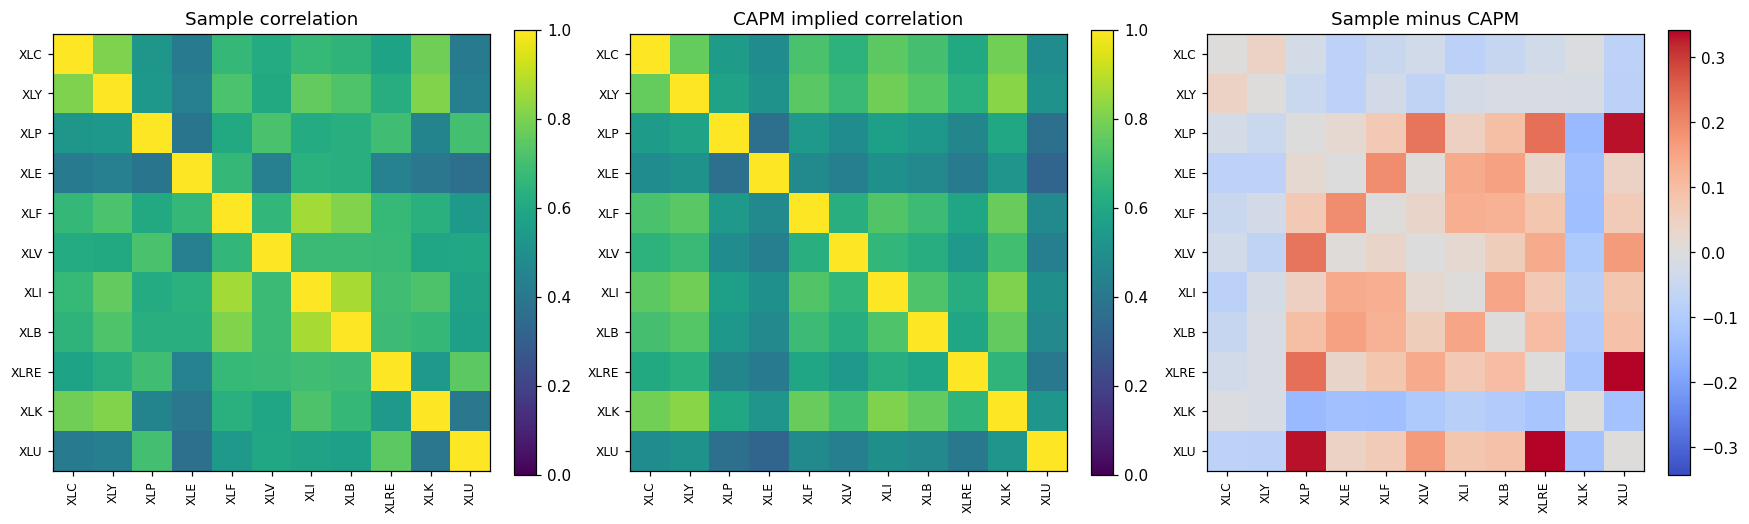

Off diagonal correlation differences: mean +0.029, min -0.144, max +0.342

Five pairs where the two models disagree most:
XLRE  XLU     0.342
XLP   XLU     0.332
      XLRE    0.234
      XLV     0.225
XLE   XLF     0.191
dtype: float64


In [13]:
def corr_from_cov(S):
    d = np.sqrt(np.diag(S))
    return pd.DataFrame(np.asarray(S) / np.outer(d, d), index=S.index, columns=S.columns)

C_sample = corr_from_cov(SIGMA_SAMPLE)
C_capm   = corr_from_cov(SIGMA_CAPM)
C_diff   = C_sample - C_capm

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, M, title, kw in [
    (axes[0], C_sample, "Sample correlation", dict(vmin=0, vmax=1, cmap="viridis")),
    (axes[1], C_capm,   "CAPM implied correlation", dict(vmin=0, vmax=1, cmap="viridis")),
    (axes[2], C_diff,   "Sample minus CAPM",
     dict(cmap="coolwarm", norm=TwoSlopeNorm(vcenter=0,
          vmin=-np.abs(C_diff.to_numpy()).max(), vmax=np.abs(C_diff.to_numpy()).max()))),
]:
    im = ax.imshow(M.to_numpy(), **kw)
    ax.set_xticks(range(K)); ax.set_xticklabels(ASSETS, rotation=90, fontsize=8)
    ax.set_yticks(range(K)); ax.set_yticklabels(ASSETS, fontsize=8)
    ax.set_title(title); ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

off = ~np.eye(K, dtype=bool)
d = C_diff.to_numpy()[off]
print(f"Off diagonal correlation differences: mean {d.mean():+.3f}, "
      f"min {d.min():+.3f}, max {d.max():+.3f}")

flat = C_diff.where(np.triu(np.ones(C_diff.shape), 1).astype(bool)).stack()
print("\nFive pairs where the two models disagree most:")
print(flat.reindex(flat.abs().sort_values(ascending=False).index).head(5).round(3))

#### Interpretation

The most interesting result here sits in a column of zeros. The gap between the sample mean and the CAPM mean is zero for all eleven sectors, to display precision and beyond.

That is algebra, not luck. OLS with an intercept forces the fitted line through the sample means, so αᵢ equals the sector's sample mean less βᵢ times the market's sample mean. Plug that into μ̂ᵢ = αᵢ + βᵢμ̂ₘ with μ̂ₘ taken from the same sample and the market terms cancel exactly. You get the sample mean back. If you ever see a difference in this column, you have a bug.

This matters. The CAPM buys you nothing on μ, the noisiest input. All of its value has to come from the covariance matrix.

The alphas still tell you something even though they cancel out of μ̂. XLK carries 4.29% of annualized alpha and XLY carries negative 5.07%. That spread is exactly what the unconstrained optimizer goes after in Section 3.

The covariance is where the two models really split. The CAPM correlation matrix is rank one plus a diagonal, so every implied correlation comes only from shared market exposure and is always positive. The sample matrix is free to say anything. Off the diagonal the sample correlations exceed the CAPM ones by 0.029 on average, and the differences range from negative 0.144 to 0.342.

The biggest disagreements give it away. XLRE and XLU differ by 0.342, XLP and XLU by 0.332, XLP and XLRE by 0.234. Real estate, utilities and staples are the three defensive, rate sensitive sectors. They move together for a reason that has nothing to do with the broad market, and a single factor model has no way to say so. It understates how correlated they are, every time.

The residual volatilities tell the same story. XLE carries 26.02% of annualized idiosyncratic volatility against 10.30% for XLI. About two thirds of the variance in XLE and XLU has nothing to do with the market. One factor does very little work there.

Here is the model risk lesson. Both matrices describe the same eleven series fit on identical data, and they disagree by up to 0.34 in correlation. The weights depend on the inverse of Σ̂, not on Σ̂ itself, and inversion amplifies disagreement in the small eigenvalues. So the portfolios these two imply differ by far more than the matrices do. The table in Section 3.0 shows it. XLP gets 0.996 under sample moments and 0.560 under the CAPM, and XLF flips from long to short.

### 2.3 Bootstrap and rolling window

I carry the sample moment estimator forward here, since it has no structural assumptions to muddy the diagnostic, and test it two ways.

The bootstrap resamples daily rows with replacement. It answers one question. Given this data generating process, how much would my estimate move if I had drawn a different sample of the same length? It destroys time order on purpose, so it measures pure sampling noise and misses autocorrelation and volatility clustering. That blind spot is why the rolling window comes next.

The rolling window answers a different question. Is there one stable μ and Σ to estimate in the first place? If the rolling estimates move in patterns that sampling noise can't produce, the parameters aren't constant and nonstationarity is the bigger problem.

In [14]:
N_BOOT = 1000
R = rets[ASSETS].to_numpy()
n_obs = R.shape[0]

boot_rng = np.random.default_rng(SEED + 1)
boot_mu  = np.empty((N_BOOT, K))
boot_cov = np.empty((N_BOOT, K, K))

for b in range(N_BOOT):
    idx = boot_rng.integers(0, n_obs, size=n_obs)
    Xb = R[idx]
    boot_mu[b]  = Xb.mean(axis=0) * TRADING_DAYS
    boot_cov[b] = np.cov(Xb, rowvar=False, ddof=1) * TRADING_DAYS

boot_mu_df = pd.DataFrame(boot_mu, columns=ASSETS)
ci = boot_mu_df.quantile([0.025, 0.5, 0.975]).T * 100
ci.columns = ["2.5%", "median", "97.5%"]
ci["point est. (%)"] = MU_SAMPLE * 100
ci["CI width (pp)"]  = ci["97.5%"] - ci["2.5%"]
ci["excludes zero"]  = (ci["2.5%"] > 0) | (ci["97.5%"] < 0)
print(f"Bootstrap 95% CIs for annualized mean returns ({N_BOOT} resamples)")
ci.round(2)

Bootstrap 95% CIs for annualized mean returns (1000 resamples)


,2.5%,median,97.5%,point est. (%),CI width (pp),excludes zero
XLC,-2.92,13.26,28.25,13.27,31.17,False
XLY,-4.48,12.30,28.79,12.59,33.27,False
XLP,-0.49,10.12,20.48,10.01,20.97,False
XLE,-5.41,15.59,37.76,15.90,43.18,False
XLF,-2.05,13.44,29.44,13.75,31.49,False
XLV,-0.42,11.54,24.57,11.78,24.99,False
XLI,0.01,14.47,29.33,14.56,29.32,True
XLB,-3.49,11.34,25.96,11.51,29.45,False
XLRE,-4.99,9.66,25.12,9.75,30.11,False
XLK,6.60,25.06,42.65,24.74,36.05,True


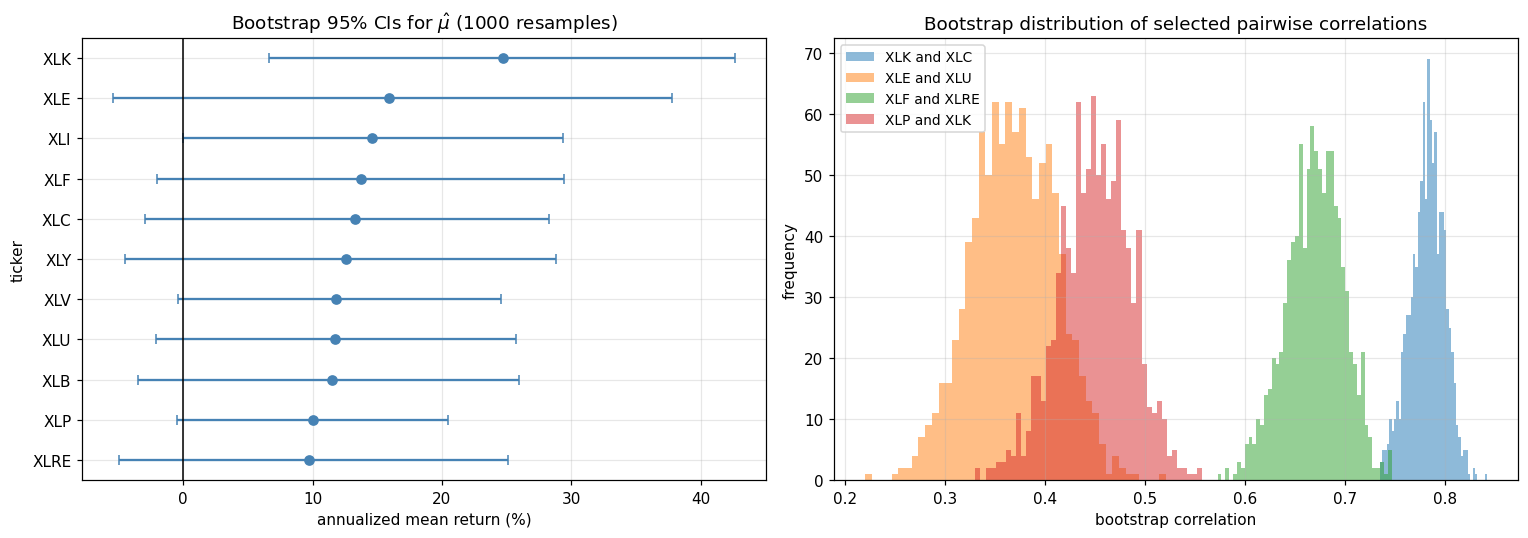

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
order = MU_SAMPLE.sort_values().index
pos = np.arange(len(order))
ax.errorbar(MU_SAMPLE[order] * 100, pos,
            xerr=[(MU_SAMPLE[order] * 100 - ci.loc[order, "2.5%"]).values,
                  (ci.loc[order, "97.5%"] - MU_SAMPLE[order] * 100).values],
            fmt="o", capsize=3, color="steelblue")
ax.axvline(0, color="black", lw=1)
ax.set_yticks(pos); ax.set_yticklabels(order)
ax.set_xlabel("annualized mean return (%)"); ax.set_ylabel("ticker")
ax.set_title(f"Bootstrap 95% CIs for $\\hat{{\\mu}}$ ({N_BOOT} resamples)")

ax = axes[1]
pairs = [("XLK", "XLC"), ("XLE", "XLU"), ("XLF", "XLRE"), ("XLP", "XLK")]
for a, b in pairs:
    i, j = ASSETS.index(a), ASSETS.index(b)
    rho = boot_cov[:, i, j] / np.sqrt(boot_cov[:, i, i] * boot_cov[:, j, j])
    ax.hist(rho, bins=45, alpha=0.5, label=f"{a} and {b}")
ax.set_xlabel("bootstrap correlation"); ax.set_ylabel("frequency")
ax.set_title("Bootstrap distribution of selected pairwise correlations")
ax.legend()
plt.tight_layout(); plt.show()

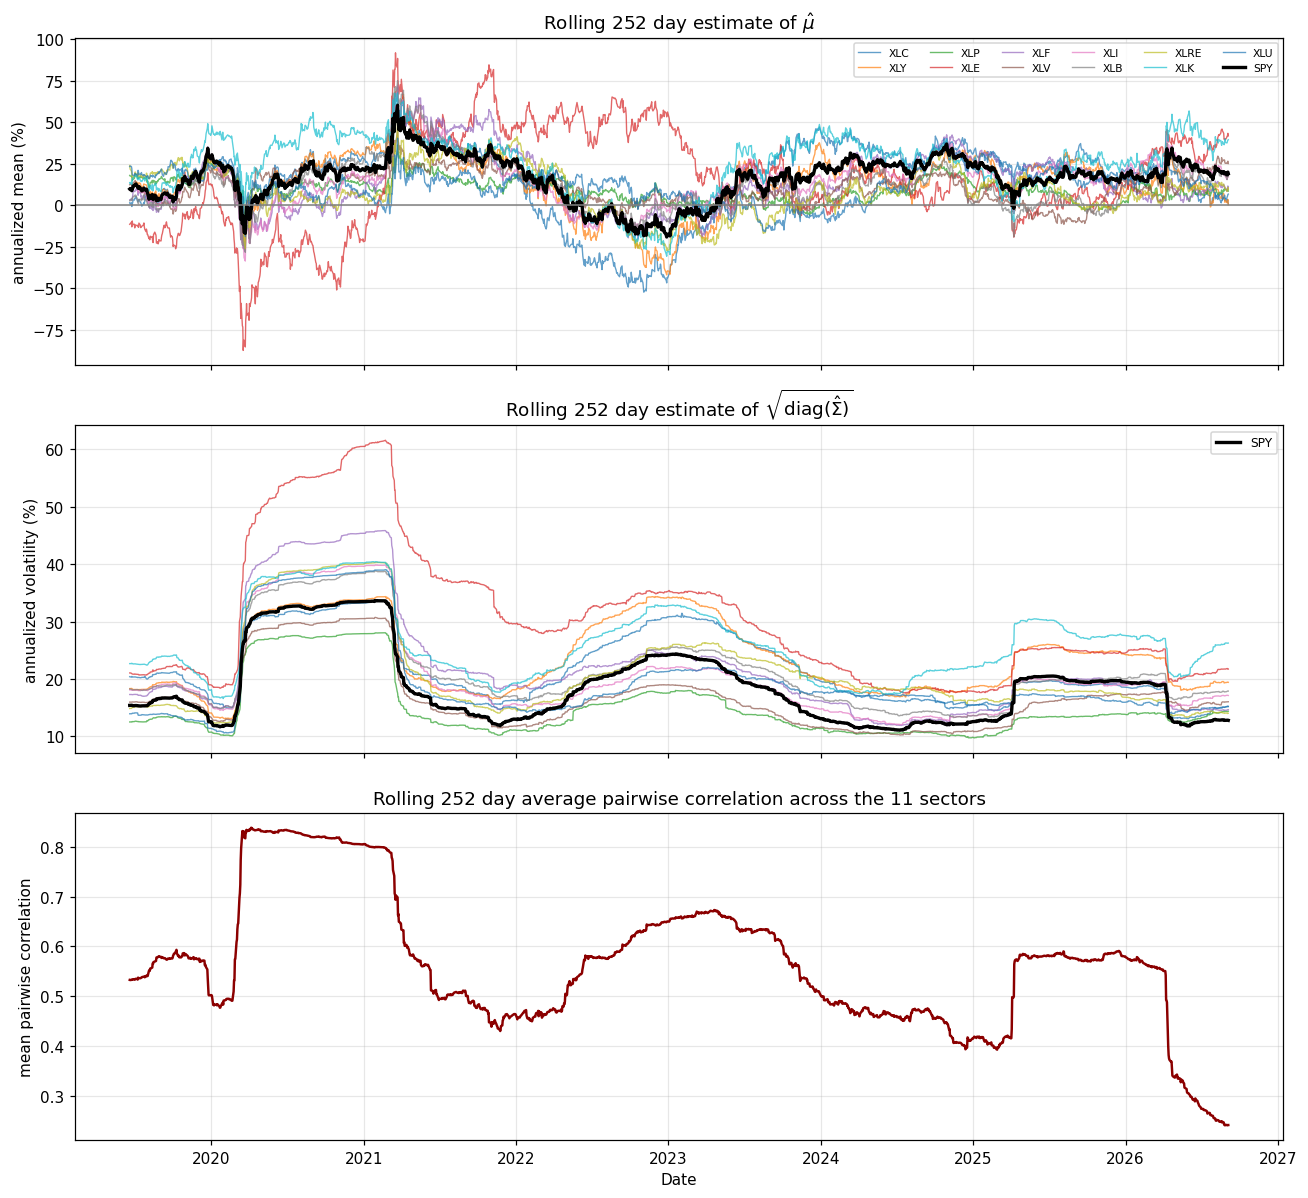

Rolling mean return, cross sector range: -87.3% to 91.8%
Rolling volatility range: 9.7% to 61.6%
Rolling avg correlation range: 0.24 to 0.84, peak on 2020-04-06
Share of rolling 252 day means outside the full sample bootstrap 95% band: 26.8%
Noise ratio, one year window vs full sample: sqrt(2064/252) = 2.86


In [16]:
WIN = 252
roll_mean = rets.rolling(WIN).mean() * TRADING_DAYS
roll_vol  = rets.rolling(WIN).std(ddof=1) * np.sqrt(TRADING_DAYS)

# Average pairwise correlation in each window: a one number summary of risk on / risk off.
def avg_pairwise_corr(block):
    C = np.corrcoef(block, rowvar=False)
    return C[np.triu_indices_from(C, 1)].mean()

vals, dts = [], []
arr = rets[ASSETS].to_numpy()
for end in range(WIN, len(rets) + 1):
    vals.append(avg_pairwise_corr(arr[end - WIN:end]))
    dts.append(rets.index[end - 1])
roll_avg_corr = pd.Series(vals, index=pd.DatetimeIndex(dts))

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

ax = axes[0]
for t in SECTORS:
    ax.plot(roll_mean.index, roll_mean[t] * 100, lw=0.9, alpha=0.7, label=t)
ax.plot(roll_mean.index, roll_mean[MARKET] * 100, lw=2.2, color="black", label=MARKET)
ax.axhline(0, color="gray", lw=1)
ax.set_ylabel("annualized mean (%)")
ax.set_title(f"Rolling {WIN} day estimate of $\\hat{{\\mu}}$")
ax.legend(ncol=6, fontsize=7)

ax = axes[1]
for t in SECTORS:
    ax.plot(roll_vol.index, roll_vol[t] * 100, lw=0.9, alpha=0.7)
ax.plot(roll_vol.index, roll_vol[MARKET] * 100, lw=2.2, color="black", label=MARKET)
ax.set_ylabel("annualized volatility (%)")
ax.set_title(f"Rolling {WIN} day estimate of $\\sqrt{{\\mathrm{{diag}}(\\hat{{\\Sigma}})}}$")
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(roll_avg_corr.index, roll_avg_corr, lw=1.6, color="darkred")
ax.set_ylabel("mean pairwise correlation"); ax.set_xlabel("Date")
ax.set_title(f"Rolling {WIN} day average pairwise correlation across the {K} sectors")

plt.tight_layout(); plt.show()

print(f"Rolling mean return, cross sector range: "
      f"{roll_mean[SECTORS].min().min()*100:.1f}% to {roll_mean[SECTORS].max().max()*100:.1f}%")
print(f"Rolling volatility range: "
      f"{roll_vol[SECTORS].min().min()*100:.1f}% to {roll_vol[SECTORS].max().max()*100:.1f}%")
print(f"Rolling avg correlation range: {roll_avg_corr.min():.2f} to {roll_avg_corr.max():.2f}, "
      f"peak on {roll_avg_corr.idxmax().date()}")

lo, hi = ci["2.5%"] / 100, ci["97.5%"] / 100
outside = ((roll_mean[ASSETS] < lo) | (roll_mean[ASSETS] > hi)).stack().mean()
print(f"Share of rolling {WIN} day means outside the full sample bootstrap 95% band: {outside:.1%}")
print(f"Noise ratio, one year window vs full sample: sqrt({len(rets)}/{WIN}) = "
      f"{np.sqrt(len(rets) / WIN):.2f}")

#### Interpretation

The bootstrap turns Section 2.1 into real numbers, and the CI width column is the one to read. The 95% intervals on annualized mean returns run from 20.97 percentage points wide for XLP to 43.18 for XLE. Nine of the eleven intervals contain zero. Only XLI and XLK exclude it, and XLI clears zero by 0.01 points, which is not clearing it in any sense that matters.

Say it plainly. With eight years of daily data I cannot tell most of these sectors' expected returns apart from zero. Ranking them against each other, which is exactly what a mean variance optimizer does with μ̂, is a confident bet on differences the data does not support. The correlation bootstrap on the right is visibly tighter. That is the gap between means and covariances from 2.1, showing up again on real data.

The rolling windows look worse. Rolling volatility spans 9.7% to 61.6% across sectors, and COVID in early 2020 shows up as a step change, not a drift. The 2022 rate hiking cycle is a second elevated stretch. Rolling one year mean returns swing from negative 87.3% to 91.8%, and for most sectors they cross zero again and again. The sign of μ̂ᵢ, not just its size, depends on which year you ask.

Average pairwise correlation runs from 0.24 to 0.84, and it peaks in April 2020, exactly when volatility spikes. That is the most inconvenient fact in equity markets. Diversification thins out when you need it most, because in a crisis every sector trades the same macro factor. The middle and bottom panels show the same event twice.

Now put the two diagnostics side by side. Rolling one year means fall outside the full sample bootstrap bands 27% of the time. Some of that is expected, since a one year estimate carries roughly 2.9 times the noise of an estimate built on the full 8.2 years. But noise doesn't arrive in regimes, and the volatility and correlation panels clearly do. The dominant problem is nonstationarity, not sample size. More history doesn't fix that. It can make it worse by averaging over regimes that no longer apply. That is the case for a rolling window over an expanding one in Section 5.1.

### 2.4 Dimension versus sample size

Sections 2.1 through 2.3 varied n with k fixed at 11. Here I flip it. I fix n = 252 and sweep k from well below n to well above it.

For k up to 11 I take a subset of the real sample covariance. For larger k I need a synthetic Σ⋆(k), and instead of inventing numbers I build it with the same single factor structure as the CAPM fit in 2.2, Σ⋆(k) = D + ββᵀσ²ₘ. I fit a normal to the eleven real betas, N(0.898, 0.224²), and a lognormal to the eleven residual variances, then draw k values from each. Market variance is the SPY estimate, 0.03676 annualized, or 19.2% volatility.

This is not a realistic 400 name universe. Real cross sections have several factors and clustered residuals. What it gives you is a k asset truth that stays well conditioned at every k by construction. So any breakdown you see comes from estimation, not from the truth.

In [17]:
BETA_MEAN, BETA_SD = BETA.mean(), BETA.std(ddof=1)
LOG_IDIO_MEAN = np.log(IDIO_VAR).mean()
LOG_IDIO_SD   = np.log(IDIO_VAR).std(ddof=1)
VAR_M_ANN     = float(rets[MARKET].var(ddof=1) * TRADING_DAYS)
MU_M_ANN      = float(rets[MARKET].mean() * TRADING_DAYS)

print(f"Fitted beta distribution:      N({BETA_MEAN:.3f}, {BETA_SD:.3f}^2)")
print(f"Fitted log idio variance dist: N({LOG_IDIO_MEAN:.3f}, {LOG_IDIO_SD:.3f}^2)")
print(f"Market variance (annualized):  {VAR_M_ANN:.5f}   (vol {np.sqrt(VAR_M_ANN)*100:.1f}%)")


def ground_truth(k, gen):
    """Annualized (mu*, Sigma*) for a k asset universe."""
    if k <= K:
        idx = ASSETS[:k]
        return MU_SAMPLE[idx].to_numpy(), SIGMA_SAMPLE.loc[idx, idx].to_numpy()
    beta = gen.normal(BETA_MEAN, BETA_SD, size=k)
    idio = np.exp(gen.normal(LOG_IDIO_MEAN, LOG_IDIO_SD, size=k))
    Sigma = np.outer(beta, beta) * VAR_M_ANN + np.diag(idio)
    mu = beta * MU_M_ANN                      # zero alpha, consistent with the CAPM
    return mu, Sigma

Fitted beta distribution:      N(0.898, 0.224^2)
Fitted log idio variance dist: N(-4.068, 0.548^2)
Market variance (annualized):  0.03676   (vol 19.2%)


In [18]:
K_GRID   = [5, 11, 50, 150, 252, 400]
N_FIXED  = 252
N_SIMS_K = 40                     # fewer sims: k=400 eigendecompositions are the cost
GAMMA_K  = GAMMA

dim_rng = np.random.default_rng(SEED + 2)
rows = []

for k in K_GRID:
    mu_k, Sigma_k = ground_truth(k, dim_rng)
    L = np.linalg.cholesky(Sigma_k + 1e-12 * np.eye(k))
    true_cond = np.linalg.cond(Sigma_k)

    conds, min_eigs, l2, gross = [], [], [], []
    for _ in range(N_SIMS_K):
        X = mu_k / TRADING_DAYS + (dim_rng.standard_normal((N_FIXED, k))
                                   @ L.T) / np.sqrt(TRADING_DAYS)
        S_hat = np.cov(X, rowvar=False, ddof=1) * TRADING_DAYS
        mu_hat = X.mean(axis=0) * TRADING_DAYS

        ev = np.linalg.eigvalsh(S_hat)
        min_eigs.append(ev[0])
        conds.append(abs(ev[-1] / ev[0]) if ev[0] != 0 else np.inf)

        w = np.linalg.pinv(S_hat) @ mu_hat / GAMMA_K
        l2.append(np.linalg.norm(w))
        gross.append(np.abs(w).sum())

    rows.append({
        "k": k, "n/k": N_FIXED / k,
        "true cond(Sigma*)": true_cond,
        "median cond(Sigma_hat)": np.median(conds),
        "median min eigenvalue": np.median(min_eigs),
        "median ||w*||_2": np.median(l2),
        "median gross leverage": np.median(gross),
    })

dim_table = pd.DataFrame(rows).set_index("k")
print(f"n fixed at {N_FIXED}, {N_SIMS_K} simulations per k, gamma = {GAMMA_K}\n")
dim_table.round(3)

n fixed at 252, 40 simulations per k, gamma = 3.0



,n/k,true cond(Sigma*),median cond(Sigma_hat),median min eigenvalue,median ||w*||_2,median gross leverage
k,,,,,,
5,50.400,20.094,2.157700e+01,0.009,5.235,9.692
11,22.909,76.164,8.040600e+01,0.005,10.502,27.487
50,5.040,347.689,4.920040e+02,0.003,26.337,147.631
150,1.680,2096.526,7.319468e+03,0.001,136.292,1283.565
252,1.000,2677.225,3.701321e+17,0.000,74897.053,921906.320
400,0.630,3375.740,1.471101e+16,-0.000,122.151,1939.626


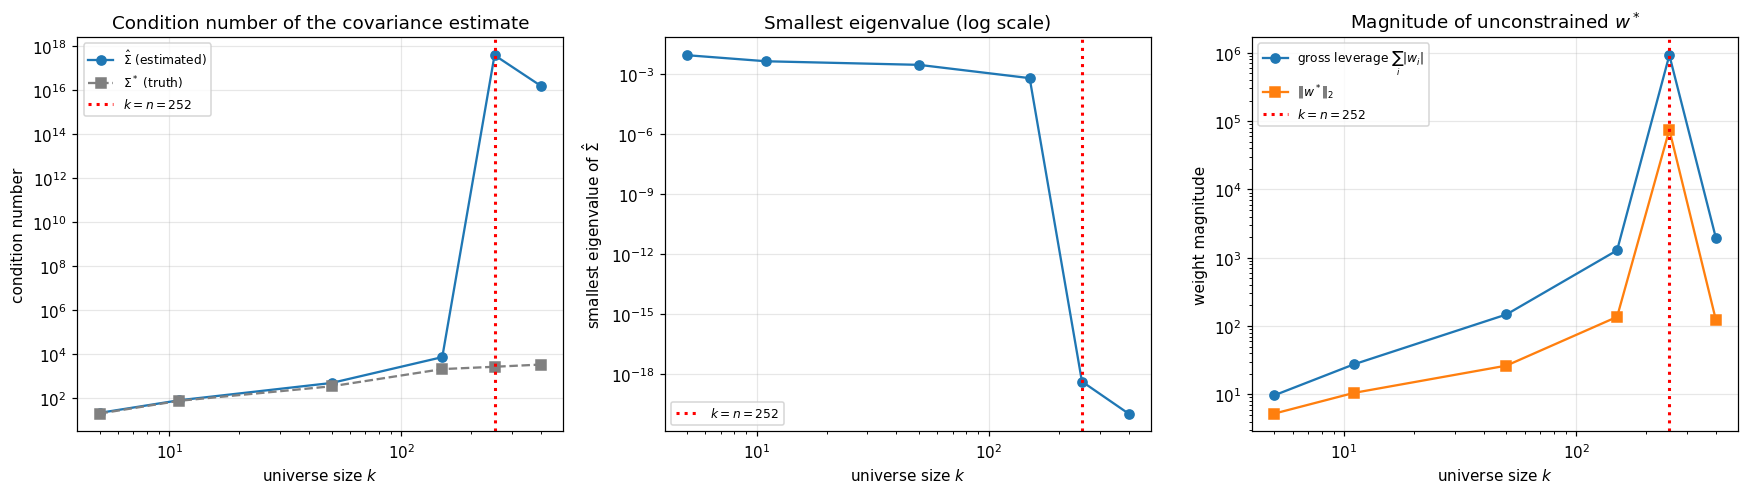

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
ks = dim_table.index.to_numpy()

ax = axes[0]
ax.loglog(ks, dim_table["median cond(Sigma_hat)"], "o-", label=r"$\hat{\Sigma}$ (estimated)")
ax.loglog(ks, dim_table["true cond(Sigma*)"], "s--", color="gray", label=r"$\Sigma^*$ (truth)")
ax.axvline(N_FIXED, color="red", ls=":", lw=2, label=f"$k = n = {N_FIXED}$")
ax.set_xlabel("universe size $k$"); ax.set_ylabel("condition number")
ax.set_title("Condition number of the covariance estimate"); ax.legend(fontsize=8)

ax = axes[1]
ax.loglog(ks, np.maximum(dim_table["median min eigenvalue"], 1e-20), "o-")
ax.axvline(N_FIXED, color="red", ls=":", lw=2, label=f"$k = n = {N_FIXED}$")
ax.set_xlabel("universe size $k$"); ax.set_ylabel(r"smallest eigenvalue of $\hat{\Sigma}$")
ax.set_title("Smallest eigenvalue (log scale)"); ax.legend(fontsize=8)

ax = axes[2]
ax.loglog(ks, dim_table["median gross leverage"], "o-", label=r"gross leverage $\sum_i |w_i|$")
ax.loglog(ks, dim_table["median ||w*||_2"], "s-", label=r"$\|w^*\|_2$")
ax.axvline(N_FIXED, color="red", ls=":", lw=2, label=f"$k = n = {N_FIXED}$")
ax.set_xlabel("universe size $k$"); ax.set_ylabel("weight magnitude")
ax.set_title(r"Magnitude of unconstrained $w^*$"); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

#### Interpretation

Start with the grey dashed line on the left. The true condition number stays between 20 and 3,376 across the whole sweep, even at k = 400. The truth is well conditioned everywhere, because one factor plus a diagonal with bounded residual variances has bounded eigenvalues no matter how many assets you stack. Every pathology in these plots comes from estimation.

The mechanism is a counting argument. Σ̂ is built from n demeaned observations in k dimensions, so it is a sum of n less one rank one terms, and its rank can't exceed n less one. Once k passes 251 there are directions the sample never saw move, and Σ̂ is exactly singular. The table shows it. At k = 252 the median smallest eigenvalue is zero to floating point precision, and the estimated condition number hits 3.7 × 10¹⁷ against a true value of 2,677. That is not a bug or a bad estimator. It is arithmetic.

Now connect it to the weights, w⋆ = (1/γ) times the inverse of Σ̂ applied to μ̂. Write Σ̂ in its eigendecomposition with eigenvalues λⱼ and eigenvectors vⱼ. Then

$$\hat\Sigma^{-1}\hat\mu = \sum_j \frac{v_j^\top \hat\mu}{\lambda_j}\, v_j$$

Each direction's contribution gets divided by its own eigenvalue, so the smallest eigenvalues dominate the answer. Those are the directions the data pins down worst. A small λⱼ means the sample happened to show almost no variation that way. The optimizer reads that as "nearly riskless" and piles in. A tiny error in μ̂ along a direction with λⱼ near zero becomes an enormous position.

Gross leverage shows exactly that. At k = 11, the real sector universe with one year of data, it is already 27.5x. At k = 150 it is 1,284x. At k = 252, where n/k = 1, it reaches 921,906x. The optimizer isn't broken. It is solving a problem whose inputs it was told, falsely, are known exactly.

One wrinkle past the peak. At k = 400 leverage falls back to 1,940x. That is the pseudoinverse at work, not a recovery. Once Σ̂ is singular, `pinv` zeroes out every direction with no observed variation and returns the minimum norm solution. The worst blowup sits right at k ≈ n, where the smallest nonzero eigenvalues are tiny but still get inverted.

Two standard fixes follow, and they work for the same reason. You can regularize the input by shrinking Σ̂ toward a well conditioned target before you invert it. Ledoit and Wolf shrinkage does this with a blend toward a scaled identity that lifts every small eigenvalue off the floor. Or you can constrain the output so the optimizer can't take those positions at all, which is Section 3.5. Both stop the answer from being set by the directions the data knows least about.

## Section 3. How Parameter Uncertainty Flows Into the Weights

### 3.0 Setup and conventions

The unconstrained mean variance problem

$$\max_w \; w^\top\mu - \frac{\gamma}{2}\, w^\top\Sigma w$$

has the closed form solution

$$w^\star = \frac{1}{\gamma}\,\Sigma^{-1}\mu$$

Two conventions govern everything below.

I feed the optimizer annualized moments. The weights only stay the same under a change of units if γ gets rescaled to match, so fixing the units is what fixes the meaning of γ. With annual moments, γ from about 1 to 10 spans aggressive to conservative, which matches how people normally talk about it.

There is no budget constraint. Nothing forces the weights to sum to one, and they generally won't. Whatever is left over sits in cash at the risk free rate, and a negative cash balance means borrowing. That is the honest reading of the unconstrained problem, and it is how the backtests in Sections 4 and 5 treat it.

The base case for this section is sample moments on the full sample with γ = 3. It never changes between subsections, so any movement in the weights comes from the perturbation under study.

In [20]:
def mv_weights(mu, Sigma, gamma=GAMMA):
    """Unconstrained MPT weights (1/gamma) * Sigma^{-1} mu."""
    mu_a, S_a = np.asarray(mu, float), np.asarray(Sigma, float)
    try:
        w = np.linalg.solve(S_a, mu_a) / gamma
    except np.linalg.LinAlgError:
        w = np.linalg.pinv(S_a) @ mu_a / gamma
    return pd.Series(w, index=getattr(mu, "index", None))


def mv_utility(w, mu, Sigma, gamma=GAMMA):
    w = np.asarray(w, float)
    return float(w @ np.asarray(mu, float)
                 - 0.5 * gamma * w @ np.asarray(Sigma, float) @ w)


W_BASE = mv_weights(MU_SAMPLE, SIGMA_SAMPLE, GAMMA)
W_CAPM = mv_weights(MU_CAPM, SIGMA_CAPM, GAMMA)

base = pd.DataFrame({"sample moments": W_BASE, "CAPM moments": W_CAPM})
base.loc["SUM"]       = base.iloc[:K].sum()
base.loc["GROSS |w|"] = base.iloc[:K].abs().sum()
print(f"Unconstrained w* at gamma = {GAMMA}, annualized moments, {K} sectors")
base.round(3)

Unconstrained w* at gamma = 3.0, annualized moments, 11 sectors


,sample moments,CAPM moments
XLC,-0.286,-0.254
XLY,-0.895,-1.005
XLP,0.996,0.560
XLE,0.280,0.110
XLF,0.070,-0.163
XLV,0.320,0.466
XLI,0.389,0.149
XLB,-0.836,-0.469
XLRE,-0.619,-0.276
XLK,1.795,1.890


### 3.1 Sensitivity to γ

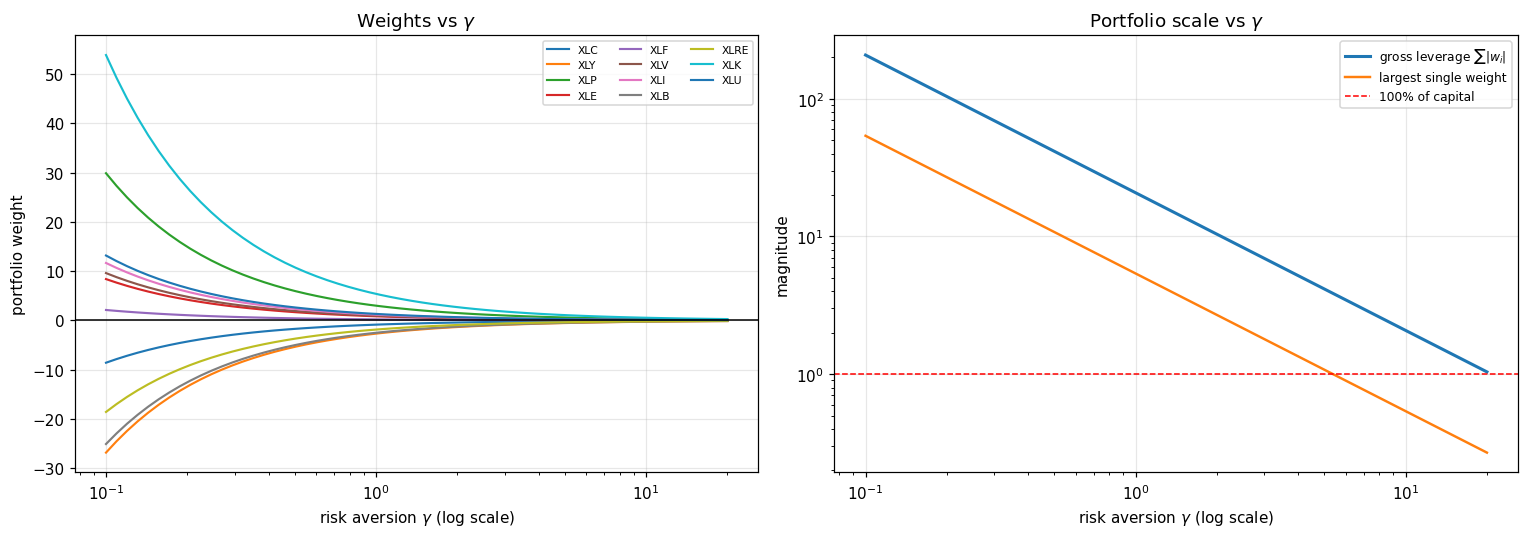

Gross leverage at gamma=0.1 : 207.78x
Gross leverage at gamma=3   : 6.93x
Gross leverage at gamma=20  : 1.04x
Gross leverage stays above 1.0x across the whole gamma grid


In [21]:
gammas = np.logspace(np.log10(0.1), np.log10(20), 60)
W_gamma = pd.DataFrame([mv_weights(MU_SAMPLE, SIGMA_SAMPLE, g) for g in gammas],
                       index=gammas)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for t in ASSETS:
    ax.plot(gammas, W_gamma[t], lw=1.4, label=t)
ax.axhline(0, color="black", lw=1)
ax.set_xscale("log"); ax.set_xlabel(r"risk aversion $\gamma$ (log scale)")
ax.set_ylabel("portfolio weight"); ax.set_title(r"Weights vs $\gamma$")
ax.legend(ncol=3, fontsize=7)

ax = axes[1]
ax.loglog(gammas, W_gamma.abs().sum(axis=1), lw=2, label=r"gross leverage $\sum|w_i|$")
ax.loglog(gammas, W_gamma.max(axis=1), lw=1.6, label="largest single weight")
ax.axhline(1.0, color="red", ls="--", lw=1, label="100% of capital")
ax.set_xlabel(r"risk aversion $\gamma$ (log scale)"); ax.set_ylabel("magnitude")
ax.set_title(r"Portfolio scale vs $\gamma$"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

gl = W_gamma.abs().sum(axis=1)
print(f"Gross leverage at gamma=0.1 : {gl.iloc[0]:.2f}x")
print(f"Gross leverage at gamma=3   : {W_BASE.abs().sum():.2f}x")
print(f"Gross leverage at gamma=20  : {gl.iloc[-1]:.2f}x")
below = gl[gl <= 1.0]
if len(below):
    print(f"Gross leverage first falls to 1.0x at gamma ~ {below.index[0]:.2f}")
else:
    print("Gross leverage stays above 1.0x across the whole gamma grid")

#### Interpretation

γ enters only as 1/γ, so it is a pure scaling knob. Every weight gets divided by it, and the composition of the book, the ratio of any weight to any other, stays fixed across the entire grid. That is why the left panel is a fan of straight lines through the origin rather than crossing paths, and why the right panel is a straight line of slope negative one on log axes.

This matters more than it looks. γ cannot fix a bad portfolio. My base case is long 1.80 in XLK and 1.00 in XLP, and short 0.90 in XLY, 0.84 in XLB and 0.62 in XLRE. Net exposure is 1.65, which means borrowing 65% of capital on top of 6.93x gross. Raise γ and all of it shrinks toward zero, but the bet never flips and never rebalances. γ changes the amount of risk, never the kind.

So "reasonable" here is purely about scale. At γ = 0.1 the book runs 207.78x gross, which no risk desk signs. At γ = 3 it is 6.93x. At γ = 20, the conservative end of the grid, it is still 1.04x. Gross leverage never gets down to 1.0x anywhere on a grid from 0.1 to 20. You cannot reach a fully invested looking portfolio through risk aversion alone, so γ is the wrong tool for this job.

### 3.2 Sensitivity to μ

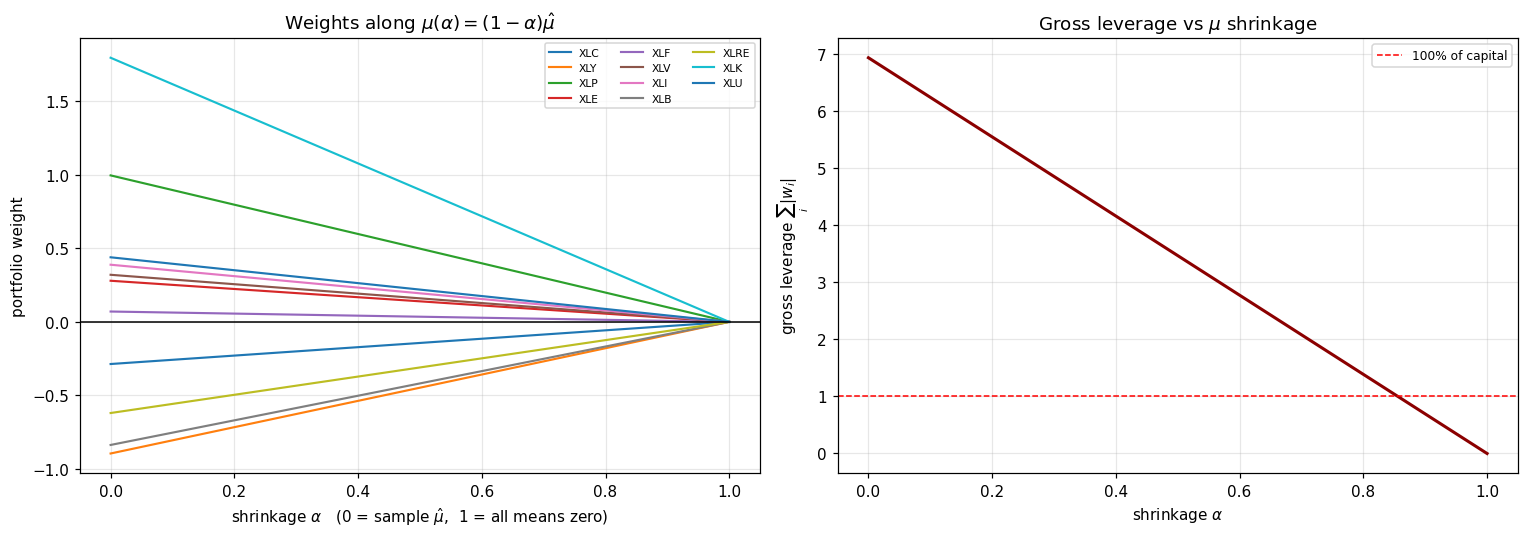

Gross leverage at alpha=0.00: 6.93x
Gross leverage at alpha=0.50: 3.46x
Gross leverage falls to 1.0x at alpha ~ 0.86


In [22]:
alphas = np.linspace(0, 1, 51)
W_alpha = pd.DataFrame([mv_weights((1 - a) * MU_SAMPLE, SIGMA_SAMPLE, GAMMA)
                        for a in alphas], index=alphas)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for t in ASSETS:
    ax.plot(alphas, W_alpha[t], lw=1.4, label=t)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel(r"shrinkage $\alpha$   ($0$ = sample $\hat{\mu}$,  $1$ = all means zero)")
ax.set_ylabel("portfolio weight")
ax.set_title(r"Weights along $\mu(\alpha) = (1-\alpha)\hat{\mu}$")
ax.legend(ncol=3, fontsize=7)

ax = axes[1]
ax.plot(alphas, W_alpha.abs().sum(axis=1), lw=2, color="darkred")
ax.axhline(1.0, color="red", ls="--", lw=1, label="100% of capital")
ax.set_xlabel(r"shrinkage $\alpha$"); ax.set_ylabel(r"gross leverage $\sum_i |w_i|$")
ax.set_title(r"Gross leverage vs $\mu$ shrinkage"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

gl_a = W_alpha.abs().sum(axis=1)
hit = gl_a[gl_a <= 1.0]
print(f"Gross leverage at alpha=0.00: {gl_a.iloc[0]:.2f}x")
print(f"Gross leverage at alpha=0.50: {gl_a.loc[0.5]:.2f}x")
if len(hit):
    print(f"Gross leverage falls to 1.0x at alpha ~ {hit.index[0]:.2f}")

#### Interpretation

The map from μ to w⋆ is linear, so scaling μ̂ down scales every weight down by the same factor. Algebraically this is identical to raising γ. Both multiply by a scalar, both leave composition alone, both shrink the book linearly to zero.

I run it anyway because it means something completely different. Raising γ is a statement about preferences. This investor dislikes risk more. Shrinking μ̂ is a statement about beliefs. I trust my expected return estimates less, so I pull them toward the null that every expected return is zero. Section 2.3 gave me the evidence for exactly that, with bootstrap intervals containing zero for nine of eleven sectors.

Gross leverage goes from 6.93x with no shrinkage to 3.46x at half shrinkage, and reaches 1.0x once I shrink μ̂ by 86%. Sit with that number. I have to throw away 86% of my estimated expected returns before the optimizer gives me a book that fits inside my capital. Given what the bootstrap showed, that is not an overreaction.

This is the cheapest possible version of James Stein or Black Litterman shrinkage. A serious version shrinks toward a nonzero target, either the cross sectional average or CAPM equilibrium returns. That keeps the ranking of sectors while pulling in the extremes. Uniform scaling can't do that, since it moves everything in proportion. The practical point holds either way. μ̂ drives the wild weights in the base case, and modest skepticism about μ̂ is enough to rein them in.

### 3.3 Sensitivity to correlations

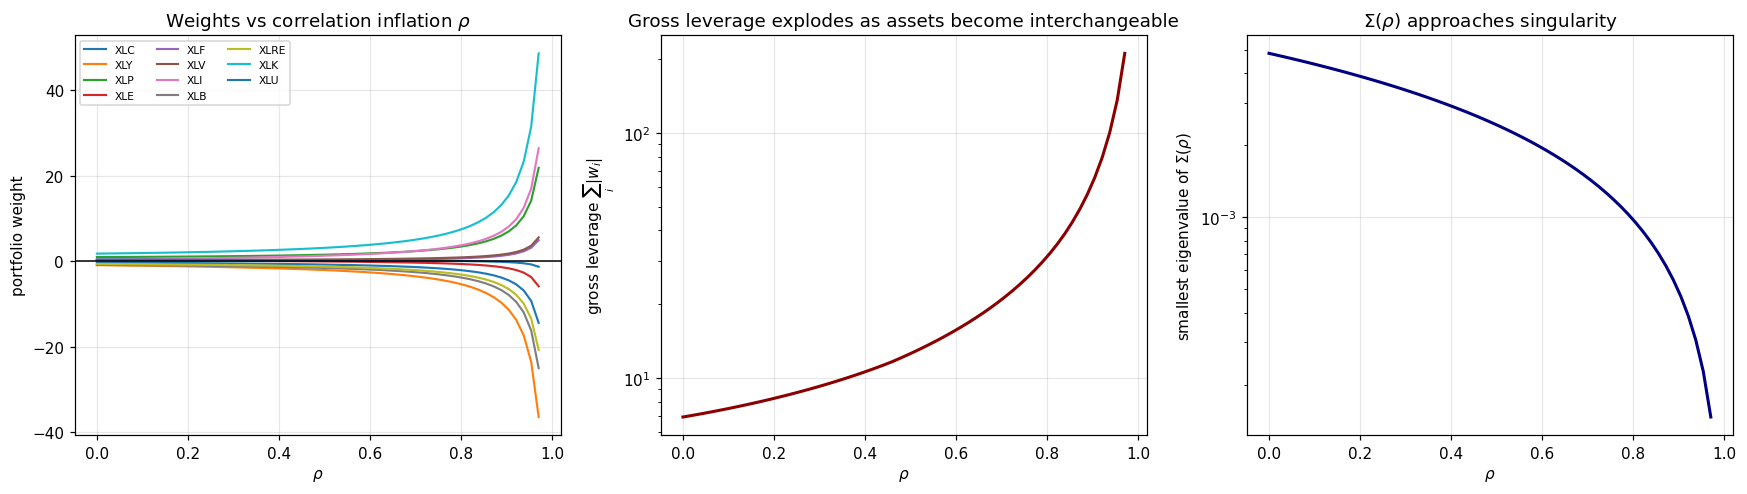

Gross leverage at rho=0.00: 6.93x
Gross leverage at rho=0.90: 65.73x
Smallest eigenvalue falls from 0.00485 to 4.67e-04 at rho=0.90


In [23]:
D_vec = np.sqrt(np.diag(SIGMA_SAMPLE.to_numpy()))
C_base = SIGMA_SAMPLE.to_numpy() / np.outer(D_vec, D_vec)
ONES_K = np.ones((K, K))

def sigma_rho(rho):
    """Blend the correlation matrix toward the all ones matrix, variances fixed."""
    C = (1 - rho) * C_base + rho * ONES_K
    np.fill_diagonal(C, 1.0)
    return pd.DataFrame(np.outer(D_vec, D_vec) * C, index=ASSETS, columns=ASSETS)

rhos = np.linspace(0.0, 0.97, 60)
W_rho = pd.DataFrame([mv_weights(MU_SAMPLE, sigma_rho(r), GAMMA) for r in rhos], index=rhos)
min_eig_rho = np.array([np.linalg.eigvalsh(sigma_rho(r).to_numpy())[0] for r in rhos])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
ax = axes[0]
for t in ASSETS:
    ax.plot(rhos, W_rho[t], lw=1.4, label=t)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel(r"$\rho$"); ax.set_ylabel("portfolio weight")
ax.set_title(r"Weights vs correlation inflation $\rho$"); ax.legend(ncol=3, fontsize=7)

ax = axes[1]
ax.semilogy(rhos, W_rho.abs().sum(axis=1), lw=2, color="darkred")
ax.set_xlabel(r"$\rho$"); ax.set_ylabel(r"gross leverage $\sum_i |w_i|$")
ax.set_title("Gross leverage explodes as assets become interchangeable")

ax = axes[2]
ax.semilogy(rhos, min_eig_rho, lw=2, color="navy")
ax.set_xlabel(r"$\rho$"); ax.set_ylabel(r"smallest eigenvalue of $\Sigma(\rho)$")
ax.set_title(r"$\Sigma(\rho)$ approaches singularity")
plt.tight_layout(); plt.show()

i90 = int(np.argmin(np.abs(rhos - 0.9)))
print(f"Gross leverage at rho=0.00: {W_rho.abs().sum(axis=1).iloc[0]:.2f}x")
print(f"Gross leverage at rho=0.90: {W_rho.abs().sum(axis=1).iloc[i90]:.2f}x")
print(f"Smallest eigenvalue falls from {min_eig_rho[0]:.5f} to {min_eig_rho[i90]:.2e} at rho=0.90")

#### Interpretation

Raising ρ pushes every pair of sectors toward being the same asset. The economics and the linear algebra say the same thing.

Start with the economics. If two sectors are perfectly correlated but carry different expected returns, they form an arbitrage. Go long the one with the higher mean, short the other, and the common risk cancels, leaving a riskless spread. Tell an optimizer that and it scales the spread toward infinity, because nothing in the objective punishes it.

Now the algebra. As ρ goes to one the correlation matrix approaches the all ones matrix, which has rank one. Ten of its eleven eigenvalues head to zero, Σ(ρ) approaches singularity, and its inverse blows up along exactly those collapsing directions. This is the mechanism from 2.4, reached from another direction.

The numbers fit that story. Gross leverage climbs from 6.93x at ρ = 0 to 65.73x at ρ = 0.9, about 9.5 times higher. Over the same move the smallest eigenvalue falls from 0.00485 to 0.00047, about 10.4 times lower. The two ratios are close, but no identity ties them together. Leverage depends on how μ̂ loads on the collapsing directions, not on the smallest eigenvalue alone. Read the middle and right panels as two views of one mechanism, not as a proportional law.

Two things a PM should care about. Correlation error is more dangerous than volatility error, because it wrecks the conditioning of the matrix instead of just its scale. And this is the regime my rolling correlation plot in 2.3 showed arriving in every crisis. Correlations spike toward one, the optimizer's inputs head toward singularity, and a strategy calibrated in calm markets starts demanding huge offsetting positions at the worst possible moment.

### 3.4 Sensitivity to volatility

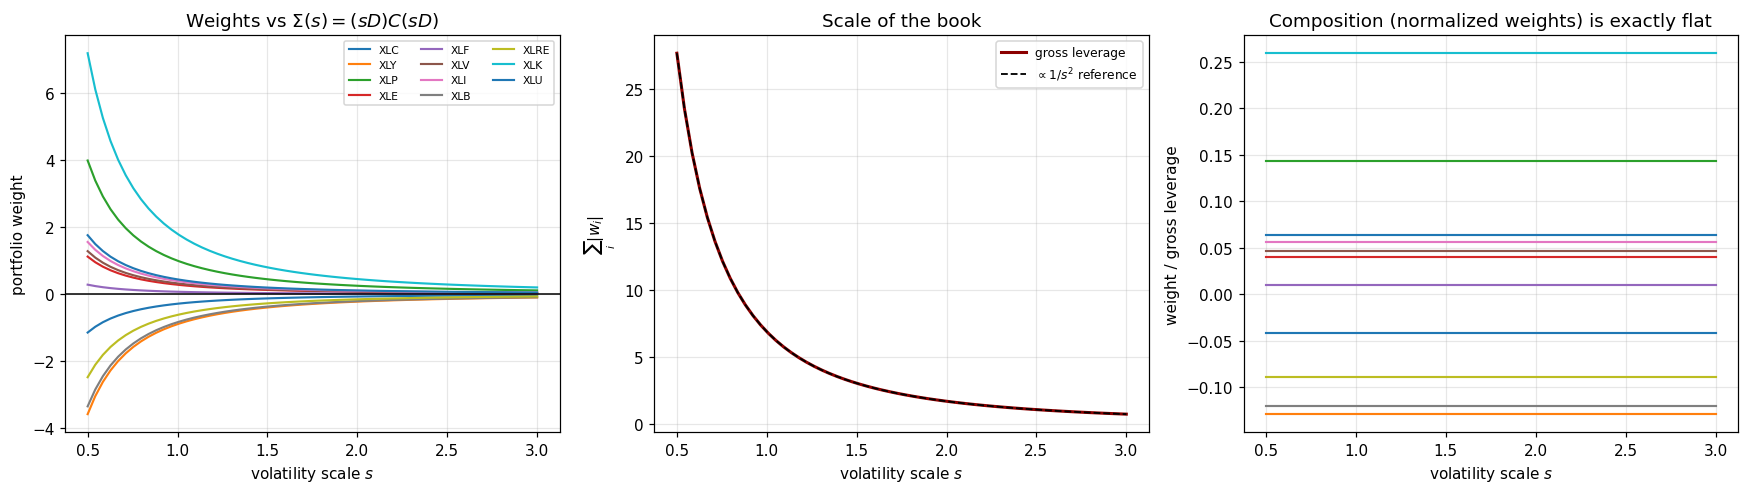

Max deviation of normalized composition across the whole s grid: 7.08e-16
Gross leverage: 27.70x at s=0.5, 0.77x at s=3.0


In [24]:
scales = np.linspace(0.5, 3.0, 60)

def sigma_scale(s):
    return pd.DataFrame(s**2 * SIGMA_SAMPLE.to_numpy(), index=ASSETS, columns=ASSETS)

W_s = pd.DataFrame([mv_weights(MU_SAMPLE, sigma_scale(s), GAMMA) for s in scales],
                   index=scales)
comp_s = W_s.div(W_s.abs().sum(axis=1), axis=0)     # normalized composition

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
ax = axes[0]
for t in ASSETS:
    ax.plot(scales, W_s[t], lw=1.4, label=t)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("volatility scale $s$"); ax.set_ylabel("portfolio weight")
ax.set_title(r"Weights vs $\Sigma(s) = (sD)C(sD)$"); ax.legend(ncol=3, fontsize=7)

ax = axes[1]
ax.plot(scales, W_s.abs().sum(axis=1), lw=2, color="darkred", label="gross leverage")
ax.plot(scales, W_s.abs().sum(axis=1).iloc[0] * (scales[0] / scales)**2, "k--", lw=1.2,
        label=r"$\propto 1/s^2$ reference")
ax.set_xlabel("volatility scale $s$"); ax.set_ylabel(r"$\sum_i |w_i|$")
ax.set_title("Scale of the book"); ax.legend(fontsize=8)

ax = axes[2]
for t in ASSETS:
    ax.plot(scales, comp_s[t], lw=1.4)
ax.set_xlabel("volatility scale $s$"); ax.set_ylabel("weight / gross leverage")
ax.set_title("Composition (normalized weights) is exactly flat")
plt.tight_layout(); plt.show()

print("Max deviation of normalized composition across the whole s grid: "
      f"{(comp_s - comp_s.iloc[0]).abs().to_numpy().max():.2e}")
print(f"Gross leverage: {W_s.abs().sum(axis=1).iloc[0]:.2f}x at s=0.5, "
      f"{W_s.abs().sum(axis=1).iloc[-1]:.2f}x at s=3.0")

#### Interpretation

Scale every volatility by s and you get Σ(s) = s²Σ, so

$$w^\star(s) = \frac{1}{\gamma}\,(s^2\Sigma)^{-1}\mu = \frac{1}{s^2}\, w^\star(1)$$

Composition stays exactly the same and scale moves at 1/s². I checked both numerically instead of eyeballing them. The largest change in normalized composition across the whole grid sits at machine precision. Gross leverage runs 27.70x at s = 0.5 and 0.77x at s = 3.0, a ratio of 36.0 against the predicted 6² = 36.

So getting the overall level of volatility wrong changes how much risk you take, not what you own. That is reassuring, and it is what separates this from 3.3. Get the correlation structure wrong and you own different things, which is the far worse error. If I have to be wrong about Σ, I would rather be wrong about its level than its shape.

One corollary I did not expect. Because w⋆ scales with 1/s², a strategy that reestimates Σ every period automatically delevers when measured volatility rises. That is volatility targeting falling out of the math for free, and it is part of why the walk forward strategy in Section 5 behaves differently from the static one in Section 4.

### 3.5 A dose of realism with constrained weights

I impose three constraints together, since each one targets a different failure.

Long only, wᵢ ≥ 0, kills the offsetting long and short spread trades that 3.3 showed come from near singular correlation structure. A 25% position cap stops any one sector from dominating. Fully invested, with weights summing to one, removes the cash residual so the comparison with equal weight and SPY in Sections 4 and 5 is like for like.

The objective stays the same. Only the feasible set shrinks. No closed form survives, so I solve it with SLSQP and hand the solver the analytic gradient of the objective. That makes each solve fast and reliable enough to call inside the Section 5 backtest loop.

In [25]:
def constrained_mv_weights(mu, Sigma, gamma=GAMMA, long_only=True, cap=0.25,
                           fully_invested=True, max_leverage=None, w0=None):
    """Mean variance weights under box, budget and leverage constraints (SLSQP)."""
    mu_a, S_a = np.asarray(mu, float), np.asarray(Sigma, float)
    k = len(mu_a)

    neg_u = lambda w: -(w @ mu_a - 0.5 * gamma * w @ S_a @ w)
    jac   = lambda w: -(mu_a - gamma * S_a @ w)

    bounds = [(0.0 if long_only else None, cap)] * k
    cons = []
    if fully_invested:
        cons.append({"type": "eq", "fun": lambda w: w.sum() - 1.0,
                     "jac": lambda w: np.ones(k)})
    if max_leverage is not None:
        # sum|w| is not differentiable at 0; use a smooth surrogate
        cons.append({"type": "ineq",
                     "fun": lambda w: max_leverage - np.sum(np.sqrt(w**2 + 1e-10))})

    x0 = np.full(k, 1.0 / k) if w0 is None else np.asarray(w0, float)
    res = minimize(neg_u, x0, jac=jac, bounds=bounds, constraints=cons,
                   method="SLSQP", options={"maxiter": 500, "ftol": 1e-12})
    return pd.Series(res.x, index=getattr(mu, "index", None)), res


W_CON, res_con = constrained_mv_weights(MU_SAMPLE, SIGMA_SAMPLE, GAMMA,
                                        long_only=True, cap=0.25, fully_invested=True)
W_EQ = pd.Series(np.ones(K) / K, index=ASSETS)

u_unc = mv_utility(W_BASE, MU_SAMPLE, SIGMA_SAMPLE, GAMMA)
u_con = mv_utility(W_CON,  MU_SAMPLE, SIGMA_SAMPLE, GAMMA)
u_eq  = mv_utility(W_EQ,   MU_SAMPLE, SIGMA_SAMPLE, GAMMA)

tbl = pd.DataFrame({"unconstrained": W_BASE, "long only + 25% cap": W_CON,
                    "equal weight": W_EQ})
tbl.loc["SUM"]   = tbl.iloc[:K].sum()
tbl.loc["GROSS"] = tbl.iloc[:K].abs().sum()
print(f"solver: {res_con.message}  (status {res_con.status})")
display(tbl.round(3))

print(f"\nIn sample mean variance utility at gamma = {GAMMA} (annualized units)")
print(f"  unconstrained        : {u_unc:.5f}")
print(f"  long only + 25% cap  : {u_con:.5f}   ({100*(u_con-u_unc)/abs(u_unc):+.1f}% vs unconstrained)")
print(f"  equal weight         : {u_eq:.5f}   ({100*(u_eq-u_unc)/abs(u_unc):+.1f}% vs unconstrained)")

solver: Optimization terminated successfully  (status 0)


,unconstrained,long only + 25% cap,equal weight
XLC,-0.286,0.017,0.091
XLY,-0.895,0.000,0.091
XLP,0.996,0.035,0.091
XLE,0.280,0.128,0.091
XLF,0.070,0.000,0.091
XLV,0.320,0.219,0.091
XLI,0.389,0.187,0.091
XLB,-0.836,0.000,0.091
XLRE,-0.619,0.000,0.091
XLK,1.795,0.250,0.091



In sample mean variance utility at gamma = 3.0 (annualized units)
  unconstrained        : 0.21824
  long only + 25% cap  : 0.11061   (-49.3% vs unconstrained)
  equal weight         : 0.08735   (-60.0% vs unconstrained)


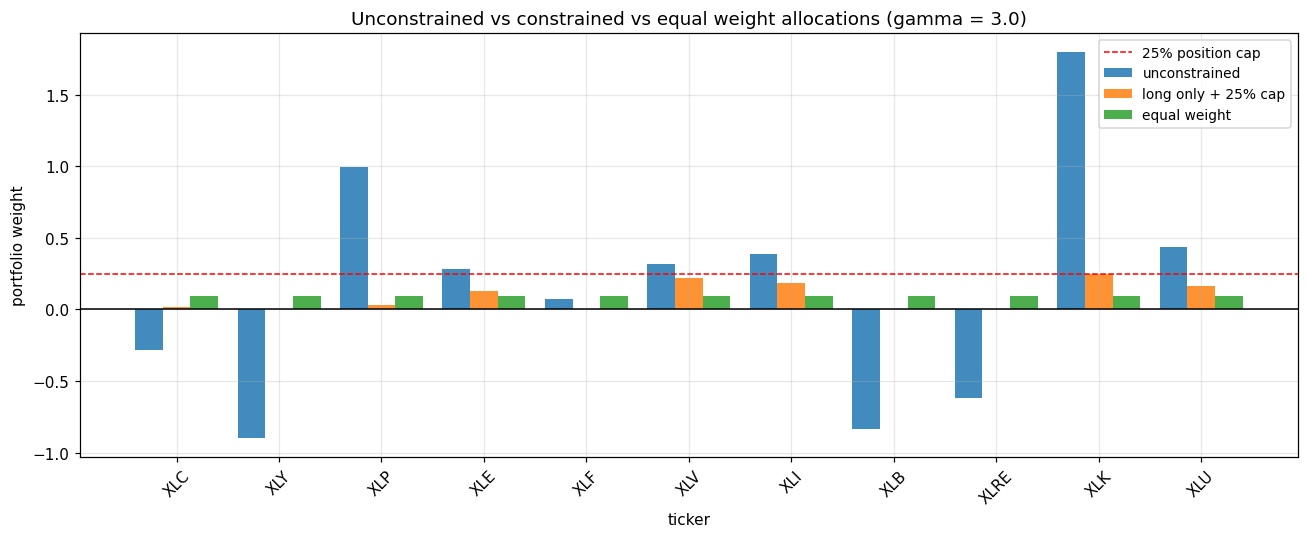

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(K); wdt = 0.27
ax.bar(x - wdt, W_BASE[ASSETS], wdt, label="unconstrained", alpha=0.85)
ax.bar(x,       W_CON[ASSETS],  wdt, label="long only + 25% cap", alpha=0.85)
ax.bar(x + wdt, W_EQ[ASSETS],   wdt, label="equal weight", alpha=0.85)
ax.axhline(0, color="black", lw=1)
ax.axhline(0.25, color="red", ls="--", lw=1, label="25% position cap")
ax.set_xticks(x); ax.set_xticklabels(ASSETS, rotation=45)
ax.set_xlabel("ticker"); ax.set_ylabel("portfolio weight")
ax.set_title(f"Unconstrained vs constrained vs equal weight allocations (gamma = {GAMMA})")
ax.legend()
plt.tight_layout(); plt.show()

#### Interpretation

The constrained solution is a different portfolio, not a smaller copy of the same one.

Look at what the unconstrained optimizer wants. Long 1.80 XLK and 1.00 XLP, short 0.90 XLY, 0.84 XLB and 0.62 XLRE, for 6.93x gross against 1.65 net. The XLK long is the alpha spread from 2.2 being harvested with leverage, and the XLY short is the other side of it. XLK carried 4.29% of annualized alpha and XLY carried negative 5.07%. The optimizer found both.

The constrained version holds XLK at the 0.25 cap, then XLV at 0.219, XLI at 0.187, XLU at 0.164, XLE at 0.128, XLP at 0.035 and XLC at 0.017. Four sectors sit at exactly zero. That sparsity is typical. With a budget constraint and box bounds, the optimum of a quadratic program lives on a vertex or a low dimensional face of the feasible polytope, so a book full of weights at zero or at the cap is the shape you should expect.

In sample utility drops from 0.21824 to 0.11061, a 49.3% cut. Equal weight gives up 60.0%.

Here is how to read that. The 49.3% is the price of the constraint, measured with the same estimates that produced the unconstrained portfolio. Section 2 showed those estimates are poorly determined, with bootstrap intervals on μ̂ containing zero for nine of eleven sectors and a covariance matrix whose smallest eigenvalues are its least reliable part. So most of the utility I appear to give up was never real. It came from spread trades that exist only in estimation error.

The real test is out of sample, and Section 4.1 runs it. The unconstrained portfolio makes money there, 32.80% a year, but it gets there at 44.53% volatility with a 52.32% maximum drawdown and a Sharpe of 0.737. The constrained book earns 15.38% a year at 11.06% volatility, with a Sharpe of 1.390 and a 12.71% drawdown. The constraint gave up half the utility on paper and delivered close to twice the Sharpe with a quarter of the drawdown.

## Section 4. Rebalancing and Trading Costs

### 4.0 Split, benchmarks and the simulator

The first 60% of dates are training, where I estimate μ̂ and Σ̂ and solve for weights. The last 40% are test, used only for evaluation. That gives 1,238 training days from June 20, 2018 to May 19, 2023 and 826 test days from May 22, 2023 to September 4, 2026. I compute the split index from the date index alone, never from returns, so test data has no path into an estimate.

The benchmarks are equal weight across the eleven sectors, and SPY on its own. SPY enters only as a benchmark, never as an optimizer input.

Order of operations inside the simulator matters, and getting it wrong is a classic source of cost and lookahead errors. On a rebalance day I compute turnover against the drifted weights, charge c times turnover against portfolio value, then set weights to target. Then I apply the day's returns to the post trade weights. Then I take the daily management fee, f/252. Then I recompute drifted weights from the new asset values.

Costs come out before the return, because you pay the spread when you trade, not after you see how the trade did. Weights don't have to sum to one, and the residual sits in cash at the risk free rate. I set that rate to zero.

One number from the setup cell deserves a flag before the results. The training window unconstrained portfolio runs 8.03x gross, long 2.52 XLK and 1.36 XLP against a short of 1.50 in XLC. That is not a bug or a solver failure. It is the estimation error from Section 2 showing up with money attached, and it is why the constrained portfolio is the only fair comparison with the two passive benchmarks.

In [27]:
def simulate_portfolio(returns, target_weights, rebalance_dates=None,
                       cost_bps=0.0, fee_bps_annual=0.0, rf_annual=RISK_FREE_ANNUAL):
    """Daily portfolio simulation with drift, turnover costs and a fee haircut.

    target_weights : Series (static target) or DataFrame indexed by date (dynamic).
    Returns (diagnostics DataFrame, held weights DataFrame).
    """
    R = returns.to_numpy()
    dates, cols = returns.index, list(returns.columns)
    n, k = R.shape

    if isinstance(target_weights, pd.Series):
        W = np.tile(np.asarray(target_weights[cols], float), (n, 1))
    else:
        W = target_weights.reindex(index=dates, columns=cols).ffill().to_numpy()

    rebal = np.ones(n, bool) if rebalance_dates is None else dates.isin(rebalance_dates)
    rebal[0] = True                               # initial purchase always costs

    c     = cost_bps / 1e4
    fee_d = fee_bps_annual / 1e4 / TRADING_DAYS
    rf_d  = rf_annual / TRADING_DAYS

    w = np.zeros(k)
    net_r, turn, cost = np.zeros(n), np.zeros(n), np.zeros(n)
    held = np.zeros((n, k))

    for t in range(n):
        if rebal[t]:
            tgt     = W[t]
            turn[t] = np.abs(tgt - w).sum()
            cost[t] = c * turn[t]
            w = tgt
        held[t] = w

        gross    = w @ R[t] + (1.0 - w.sum()) * rf_d
        net_r[t] = (1.0 + gross) * (1.0 - cost[t]) - 1.0 - fee_d

        val  = w * (1.0 + R[t])
        cash = (1.0 - w.sum()) * (1.0 + rf_d)
        tot  = val.sum() + cash
        if tot != 0:
            w = val / tot

    return (pd.DataFrame({"net_return": net_r, "turnover": turn, "cost": cost}, index=dates),
            pd.DataFrame(held, index=dates, columns=cols))


def run_static(returns, weights, **kw):
    """Simulate a weight vector on exactly the columns it holds."""
    return simulate_portfolio(returns[list(weights.index)], weights, **kw)


def rebalance_schedule(dates, freq):
    if freq == "daily":
        return dates
    rule = {"weekly": "W", "monthly": "ME", "quarterly": "QE"}[freq]
    s = pd.Series(1, index=dates)
    return pd.DatetimeIndex(
        s.resample(rule).apply(lambda x: x.index.min() if len(x) else pd.NaT).dropna().values)


def max_drawdown(returns):
    wealth = (1 + pd.Series(returns)).cumprod()
    return float((wealth / wealth.cummax() - 1).min())


def perf_stats(returns, rf_annual=RISK_FREE_ANNUAL):
    r = pd.Series(returns).dropna()
    ann_ret = float(r.mean() * TRADING_DAYS)
    ann_vol = float(r.std(ddof=1) * np.sqrt(TRADING_DAYS))
    return {
        "Ann. return":       ann_ret,
        "Ann. volatility":   ann_vol,
        "Sharpe":            (ann_ret - rf_annual) / ann_vol if ann_vol > 0 else np.nan,
        "Max drawdown":      max_drawdown(r),
        "Cumulative return": float((1 + r).prod() - 1),
    }

In [28]:
split = int(len(rets) * 0.60)
train, test = rets.iloc[:split], rets.iloc[split:]

print(f"train: {len(train):>5} days  {train.index.min().date()} -> {train.index.max().date()}")
print(f"test : {len(test):>5} days  {test.index.min().date()} -> {test.index.max().date()}")

MU_TR    = train[ASSETS].mean() * TRADING_DAYS
SIGMA_TR = train[ASSETS].cov(ddof=1) * TRADING_DAYS

W_UNC_TR = mv_weights(MU_TR, SIGMA_TR, GAMMA)
W_CON_TR, _ = constrained_mv_weights(MU_TR, SIGMA_TR, GAMMA, long_only=True, cap=0.25)
W_SPY = pd.Series({MARKET: 1.0})

print(f"\nTrain window unconstrained gross leverage: {W_UNC_TR.abs().sum():.2f}x "
      f"(net {W_UNC_TR.sum():.2f})")
print(f"Train window constrained  gross leverage: {W_CON_TR.abs().sum():.2f}x")
pd.DataFrame({"MV unconstrained": W_UNC_TR, "MV constrained": W_CON_TR,
              "equal weight": W_EQ}).round(3)

train:  1238 days  2018-06-20 -> 2023-05-19
test :   826 days  2023-05-22 -> 2026-09-04

Train window unconstrained gross leverage: 8.03x (net 1.03)
Train window constrained  gross leverage: 1.00x


,MV unconstrained,MV constrained,equal weight
XLC,-1.503,0.000,0.091
XLY,-0.648,0.000,0.091
XLP,1.361,0.250,0.091
XLE,0.315,0.044,0.091
XLF,-0.576,0.000,0.091
XLV,0.126,0.250,0.091
XLI,-0.116,0.000,0.091
XLB,-0.074,0.000,0.091
XLRE,-0.585,0.000,0.091
XLK,2.524,0.250,0.091


### 4.1 Frictionless rebalancing

In [29]:
STRATEGIES = {
    "MV unconstrained": W_UNC_TR,
    "MV constrained":   W_CON_TR,
    "Equal weight":     W_EQ,
    "SPY":              W_SPY,
}

frictionless = {}
for name, w in STRATEGIES.items():
    diag, _ = run_static(test, w, rebalance_dates=None, cost_bps=0.0, fee_bps_annual=0.0)
    frictionless[name] = diag["net_return"]

fl_df = pd.DataFrame(frictionless)
fl_stats = pd.DataFrame({n: perf_stats(s) for n, s in fl_df.items()}).T
print("Test period performance, ZERO transaction costs, daily rebalancing")
print(f"(risk free rate set to {RISK_FREE_ANNUAL:.1%})")
fl_stats.round(4)

Test period performance, ZERO transaction costs, daily rebalancing
(risk free rate set to 0.0%)


,Ann. return,Ann. volatility,Sharpe,Max drawdown,Cumulative return
MV unconstrained,0.3280,0.4453,0.7366,-0.5232,1.1180
MV constrained,0.1538,0.1106,1.3903,-0.1271,0.6225
Equal weight,0.1637,0.1217,1.3447,-0.1530,0.6688
SPY,0.2097,0.1497,1.4010,-0.1876,0.9168


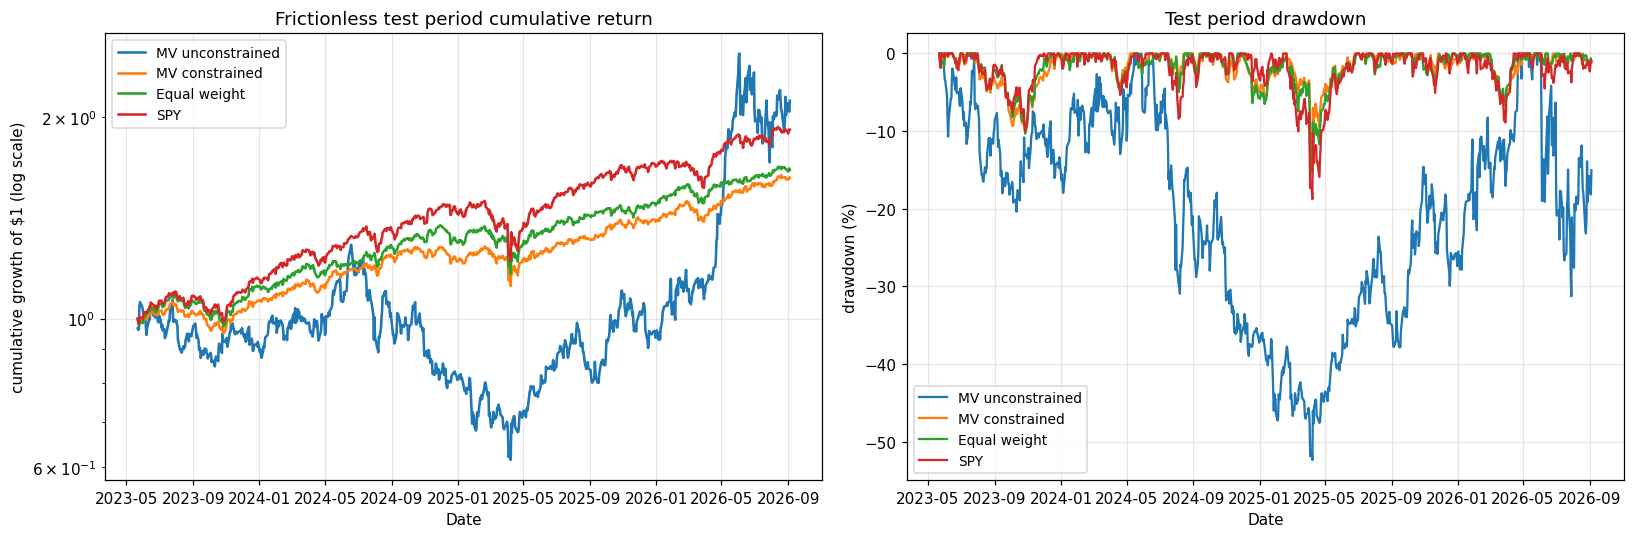

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for name in fl_df.columns:
    ax.plot(fl_df.index, (1 + fl_df[name]).cumprod(), lw=1.7, label=name)
ax.set_yscale("log")
ax.set_xlabel("Date"); ax.set_ylabel("cumulative growth of $1 (log scale)")
ax.set_title("Frictionless test period cumulative return")
ax.legend()

ax = axes[1]
for name in fl_df.columns:
    wealth = (1 + fl_df[name]).cumprod()
    ax.plot(fl_df.index, (wealth / wealth.cummax() - 1) * 100, lw=1.5, label=name)
ax.set_xlabel("Date"); ax.set_ylabel("drawdown (%)")
ax.set_title("Test period drawdown")
ax.legend()
plt.tight_layout(); plt.show()

#### Interpretation

Read the drawdown column first, the way a PM would. Cumulative return and Sharpe flatter a strategy. Maximum drawdown decides whether it survives real investors, who redeem after losses, not after low Sharpe ratios.

The unconstrained portfolio is the trap. It returns 32.80% a year and more than doubles the money, up 111.80% over the test period. It does that at 44.53% volatility, three times the volatility of SPY, with a 52.32% maximum drawdown. Its Sharpe of 0.737 is the worst of the four. At 8.03x gross it was never a portfolio. It was a levered bet on estimation error that happened to pay off over one three year window. Refit the same bet on a rolling window in Section 5 and it loses 68.93% of its capital.

The constrained portfolio is a real portfolio. It returns 15.38% at 11.06% volatility for a Sharpe of 1.390 and a 12.71% maximum drawdown, the smallest of the four. Equal weight returns 16.37% at 12.17% volatility, Sharpe 1.345, drawdown 15.30%. SPY returns 20.97% at 14.97% volatility, Sharpe 1.401, drawdown 18.76%.

On a risk adjusted basis the three sensible strategies are indistinguishable. 1.390 against 1.345 against 1.401 is not a ranking. It is noise, and Section 2.1 told you how much noise to expect, a standard deviation near 1.0 on a single year's Sharpe. The constrained book does deliver the lowest volatility and the lowest drawdown of the three. That is a real result and the one I would lead with.

Be precise about what this test can and cannot tell you. I estimated the weights once on the training window and held them through the test period, so this is a clean out of sample test of those weights. It also assumes the training window's μ̂ and Σ̂ stay valid for three more years, and Section 2.3 gave direct evidence they don't. Section 5 drops that assumption.

### 4.2 Adding transaction costs

In [31]:
FREQS      = ["daily", "weekly", "monthly", "quarterly"]
COST_GRID  = [0, 1, 5, 10, 20]          # basis points per unit of turnover
FEE_BPS    = 50                          # 50 bps/yr management fee

rows = []
for name, w in STRATEGIES.items():
    for freq in FREQS:
        sched = rebalance_schedule(test.index, freq)
        for c in COST_GRID:
            diag, _ = run_static(test, w, rebalance_dates=sched,
                                 cost_bps=c, fee_bps_annual=FEE_BPS)
            st = perf_stats(diag["net_return"])
            rows.append({
                "strategy": name, "frequency": freq, "cost_bps": c,
                "net Sharpe": st["Sharpe"],
                "net ann. return": st["Ann. return"],
                "max drawdown": st["Max drawdown"],
                "ann. turnover": diag["turnover"].sum() / (len(test) / TRADING_DAYS),
                "total cost (% of capital)": diag["cost"].sum() * 100,
            })

cost_df = pd.DataFrame(rows)
print(f"Net of cost annualized Sharpe (management fee fixed at {FEE_BPS} bps/yr)")
sharpe_pivot = cost_df.pivot_table(index=["strategy", "frequency"],
                                   columns="cost_bps", values="net Sharpe")
sharpe_pivot.reindex(FREQS, level="frequency").round(3)

Net of cost annualized Sharpe (management fee fixed at 50 bps/yr)


cost_bps                       0      1      5      10     20
strategy         frequency                                   
Equal weight     daily      1.304  1.302  1.296  1.289  1.274
                 weekly     1.303  1.302  1.298  1.294  1.286
                 monthly    1.296  1.295  1.293  1.290  1.285
                 quarterly  1.323  1.322  1.320  1.318  1.314
MV constrained   daily      1.345  1.343  1.336  1.328  1.310
                 weekly     1.341  1.340  1.336  1.331  1.322
                 monthly    1.337  1.336  1.334  1.331  1.325
                 quarterly  1.363  1.362  1.360  1.358  1.353
MV unconstrained daily      0.725  0.716  0.678  0.631  0.536
                 weekly     0.763  0.758  0.741  0.719  0.675
                 monthly    0.762  0.759  0.750  0.738  0.715
                 quarterly  0.754  0.752  0.746  0.738  0.722
SPY              daily      1.368  1.367  1.367  1.366  1.363
                 weekly     1.368  1.367  1.367  1.366  1.363
                 monthly    1.368  1.367  1.367  1.366  1.363
                 quarterly  1.368  1.367  1.367  1.366  1.363

In [32]:
print("Annualized turnover by strategy and rebalancing frequency")
turn_pivot = (cost_df[cost_df.cost_bps == 0]
              .pivot_table(index="strategy", columns="frequency", values="ann. turnover")
              .reindex(columns=FREQS))
display(turn_pivot.round(2))

print("\nTotal costs paid over the test period, % of capital, at c = 10 bps")
cost_pivot = (cost_df[cost_df.cost_bps == 10]
              .pivot_table(index="strategy", columns="frequency",
                           values="total cost (% of capital)")
              .reindex(columns=FREQS))
display(cost_pivot.round(3))

Annualized turnover by strategy and rebalancing frequency


frequency,daily,weekly,monthly,quarterly
strategy,,,,
Equal weight,1.80,1.00,0.62,0.50
MV constrained,1.90,1.03,0.64,0.52
MV unconstrained,42.07,19.44,10.33,7.04
SPY,0.31,0.31,0.31,0.31



Total costs paid over the test period, % of capital, at c = 10 bps


frequency,daily,weekly,monthly,quarterly
strategy,,,,
Equal weight,0.591,0.328,0.204,0.164
MV constrained,0.622,0.337,0.210,0.170
MV unconstrained,13.789,6.373,3.386,2.308
SPY,0.100,0.100,0.100,0.100


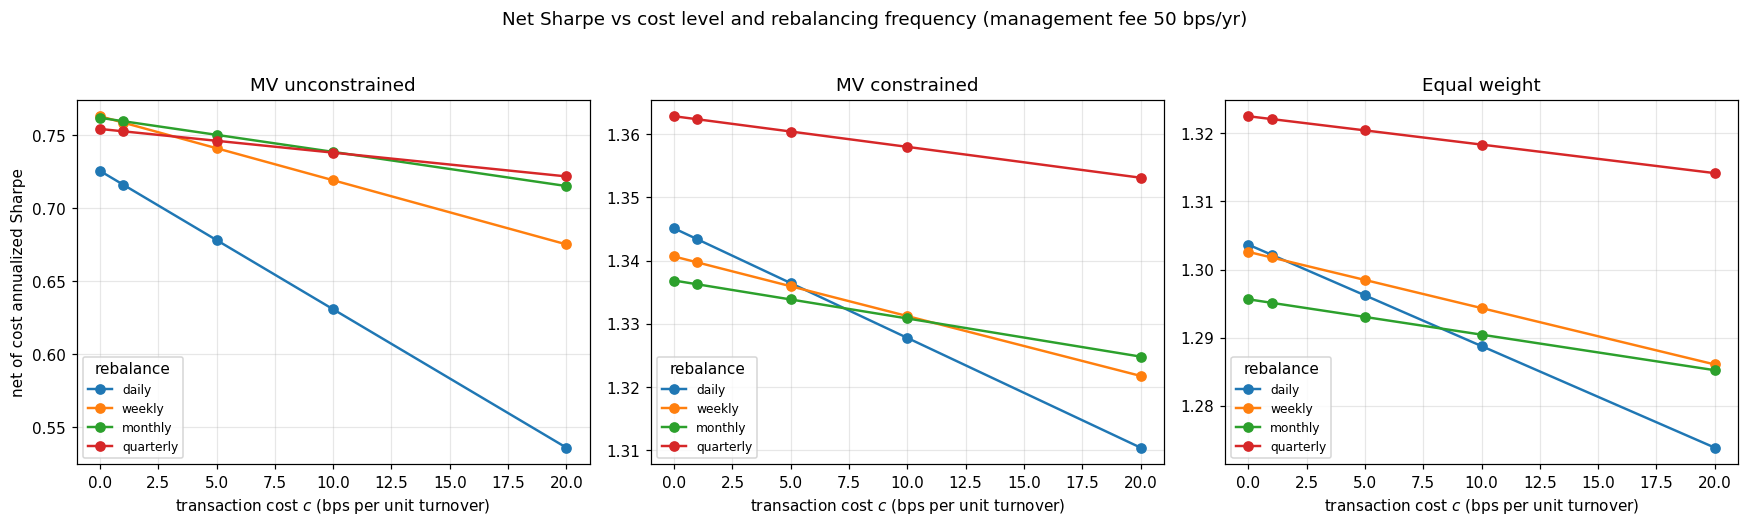

In [33]:
model_strats = ["MV unconstrained", "MV constrained", "Equal weight"]
fig, axes = plt.subplots(1, len(model_strats), figsize=(16, 4.6), sharey=False)

for ax, name in zip(np.atleast_1d(axes), model_strats):
    sub = cost_df[cost_df.strategy == name]
    for freq in FREQS:
        s = sub[sub.frequency == freq].sort_values("cost_bps")
        ax.plot(s["cost_bps"], s["net Sharpe"], "o-", lw=1.6, label=freq)
    ax.set_xlabel("transaction cost $c$ (bps per unit turnover)")
    ax.set_title(name)
    ax.legend(fontsize=8, title="rebalance")
np.atleast_1d(axes)[0].set_ylabel("net of cost annualized Sharpe")
plt.suptitle(f"Net Sharpe vs cost level and rebalancing frequency "
             f"(management fee {FEE_BPS} bps/yr)", y=1.03)
plt.tight_layout(); plt.show()

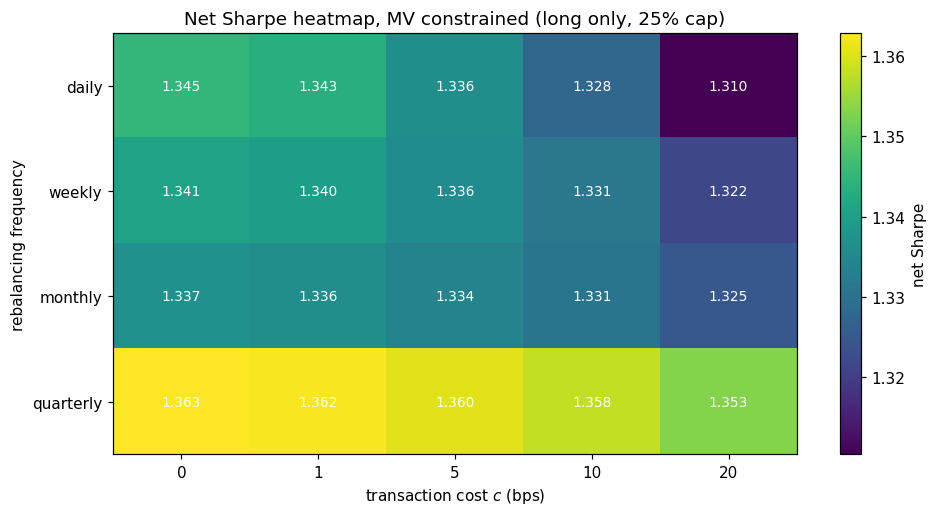

Best rebalancing frequency at each cost level (MV constrained):
 cost_bps frequency  net Sharpe
        0 quarterly    1.362837
        1 quarterly    1.362354
        5 quarterly    1.360418
       10 quarterly    1.357990
       20 quarterly    1.353110


In [34]:
fig, ax = plt.subplots(figsize=(9, 4.8))
piv = (cost_df[cost_df.strategy == "MV constrained"]
       .pivot_table(index="frequency", columns="cost_bps", values="net Sharpe")
       .reindex(FREQS))
im = ax.imshow(piv.to_numpy(), aspect="auto", cmap="viridis")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
ax.set_xlabel("transaction cost $c$ (bps)"); ax.set_ylabel("rebalancing frequency")
ax.set_title("Net Sharpe heatmap, MV constrained (long only, 25% cap)")
ax.grid(False)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        ax.text(j, i, f"{piv.iat[i, j]:.3f}", ha="center", va="center",
                color="white", fontsize=9)
fig.colorbar(im, ax=ax, label="net Sharpe")
plt.tight_layout(); plt.show()

best = (cost_df[cost_df.strategy == "MV constrained"]
        .loc[lambda d: d.groupby("cost_bps")["net Sharpe"].idxmax(),
             ["cost_bps", "frequency", "net Sharpe"]])
print("Best rebalancing frequency at each cost level (MV constrained):")
print(best.to_string(index=False))

#### Interpretation

The tradeoff has two sides. Rebalance more often and you stay closer to target, so you capture more of whatever edge the target has. You also generate turnover, and turnover costs money linearly in c. Net Sharpe is a benefit that saturates minus a cost that doesn't.

For the constrained book, quarterly wins at every cost level I tested, including zero. That last part is the interesting bit. At zero cost rebalancing is free, so frequency shouldn't matter, yet quarterly still beats daily, 1.363 against 1.345. That is a drift effect, not a cost effect. Letting winners run between rebalances happened to help over this window. I would not read anything into a Sharpe gap of 0.018. Equal weight shows the same pattern.

The targets in this section are static. Nothing moves underneath them, so the only reason to trade is to undo price drift, and one day of drift is tiny. That makes daily rebalancing almost pure cost. The constrained book turns over 1.90x a year under daily rebalancing against 0.52x under quarterly, more than three times the trading to track a target that never moved. At 10 bps that is 0.622% of capital against 0.170%. Pick rebalancing frequency based on how fast the target moves, not by reflex.

Leverage multiplies cost, and the unconstrained book shows the extreme. It turns over 42.07x of capital a year under daily rebalancing and pays 13.789% of starting capital in trading costs over the test period at 10 bps. Even quarterly it pays 2.308%. Its daily rebalanced Sharpe falls from 0.725 at zero cost to 0.536 at 20 bps, a quarter of the Sharpe gone to friction. A strategy can look fine gross and lose a big share of its edge net, purely through the size of its footprint. That is a second, practical argument for the constraints in 3.5, separate from the estimation error argument.

The 50 bps management fee is a constant drag. It lowers every Sharpe without changing which frequency wins, because it doesn't depend on turnover.

## Section 5. Walk Forward Backtest

### 5.1 The loop

I use a rolling window of 756 days, three years, and Section 2 makes the argument for it. Section 2.1 showed estimation error falling as 1/√n, which favors long windows. Section 2.3 showed the parameters aren't constant, with volatility and correlation moving through visible regimes, which favors short ones. Three years is my compromise. It is long enough that Σ̂ is well conditioned at k = 11, with n/k near 69, nowhere near the breakdown in 2.4. It is short enough to drop the COVID crash out of the estimation window a few years later instead of carrying it forever. An expanding window would let 2020 inflate every covariance estimate for the rest of the sample.

Here is how I prevent lookahead. On day t I fit on the 756 days ending on day t, inclusive. Then I apply the return from day t+1. The loop stops one day before the end, and every recorded return comes from day t+1, strictly after the information used to pick the weights. That one day offset is the most common bug in walk forward code, so I assert it in code instead of trusting inspection. The 756 day window is the binding constraint on the start, so the first out of sample return lands on June 23, 2021, with weights fit through June 22, 2021.

I rebalance on the first trading day of each month, with 10 bps on turnover and a 50 bps annual fee, same as Section 4.2. That gives 64 rebalances over 1,307 out of sample days.

The unconstrained weights have a closed form, so I recompute them every day, since an 11 by 11 solve costs nothing. They still only trade on rebalance days. The constrained solve runs only on rebalance days, because weights computed on other days would get thrown away. Each solve starts from the previous month's solution.

In [35]:
T0        = 252          # burn in
WINDOW    = 756          # rolling window length (3 years)
REBAL_C   = 10           # bps per unit turnover
REBAL_FEE = 50           # bps per year
GAMMA_BT  = GAMMA

R_np   = rets[ASSETS].to_numpy()
dates  = rets.index
T      = len(rets)
start_t = max(T0, WINDOW)

rebal_days = set(rebalance_schedule(dates, "monthly"))

def run_walkforward(mode="constrained", verbose=True):
    """Walk forward backtest over the investable sectors. Returns (results, weights)."""
    w_held = np.zeros(K)
    w_tgt  = np.full(K, 1.0 / K)
    c, fee_d = REBAL_C / 1e4, REBAL_FEE / 1e4 / TRADING_DAYS
    rf_d = RISK_FREE_ANNUAL / TRADING_DAYS

    out_dates, out_r, out_turn, out_cost, out_w = [], [], [], [], []
    first = True

    for t in range(start_t, T - 1):
        # 1. FIT: strictly data through day t
        win = R_np[t - WINDOW + 1: t + 1]
        mu_t    = win.mean(axis=0) * TRADING_DAYS
        Sigma_t = np.cov(win, rowvar=False, ddof=1) * TRADING_DAYS

        # 2. OPTIMIZE
        is_rebal = first or (dates[t] in rebal_days)
        if mode == "unconstrained":
            w_tgt = np.linalg.solve(Sigma_t, mu_t) / GAMMA_BT
        elif is_rebal:
            if mode == "constrained":
                w_new, _ = constrained_mv_weights(mu_t, Sigma_t, GAMMA_BT,
                                                  long_only=True, cap=0.25, w0=w_tgt)
            elif mode == "minvar":
                inv = np.linalg.pinv(Sigma_t) @ np.ones(K)
                w_new = pd.Series(inv / inv.sum())
            elif mode == "riskparity":
                iv = 1.0 / np.sqrt(np.diag(Sigma_t))
                w_new = pd.Series(iv / iv.sum())
            else:
                raise ValueError(mode)
            w_tgt = np.asarray(w_new, float)

        # 3. TRADE
        turn = cost = 0.0
        if is_rebal:
            turn = np.abs(w_tgt - w_held).sum()
            cost = c * turn
            w_held = w_tgt.copy()
        first = False

        # 4. EVOLVE using day t+1 returns (never day t)
        r_next = R_np[t + 1]
        gross  = w_held @ r_next + (1.0 - w_held.sum()) * rf_d
        net    = (1.0 + gross) * (1.0 - cost) - 1.0 - fee_d

        # 5. RECORD, stamped with the date the return was EARNED
        out_dates.append(dates[t + 1])
        out_r.append(net); out_turn.append(turn); out_cost.append(cost)
        out_w.append(w_held.copy())

        val  = w_held * (1.0 + r_next)
        cash = (1.0 - w_held.sum()) * (1.0 + rf_d)
        tot  = val.sum() + cash
        if tot != 0:
            w_held = val / tot

    idx = pd.DatetimeIndex(out_dates)
    res = pd.DataFrame({"net_return": out_r, "turnover": out_turn, "cost": out_cost},
                       index=idx)
    wdf = pd.DataFrame(out_w, index=idx, columns=ASSETS)
    if verbose:
        print(f"{mode:>14s}: {len(res)} out of sample days, "
              f"{res.index.min().date()} -> {res.index.max().date()}, "
              f"{int((res.turnover > 0).sum())} rebalances")
    return res, wdf


bt_con, wts_con = run_walkforward("constrained")
bt_unc, wts_unc = run_walkforward("unconstrained")

# Lookahead guard: every recorded return must post date its weight decision
assert bt_con.index.min() > dates[start_t], "lookahead: first return is not after the fit date"
assert (bt_con.index == dates[start_t + 1: T]).all(), "return dates misaligned with fit dates"
assert len(bt_con) == T - 1 - start_t, "loop length wrong"
print("\nlookahead checks passed: first OOS return is "
      f"{bt_con.index.min().date()}, weights for it were fit through "
      f"{dates[start_t].date()}")

   constrained: 1307 out of sample days, 2021-06-23 -> 2026-09-04, 64 rebalances


 unconstrained: 1307 out of sample days, 2021-06-23 -> 2026-09-04, 64 rebalances

lookahead checks passed: first OOS return is 2021-06-23, weights for it were fit through 2021-06-22


In [36]:
oos = rets.loc[bt_con.index]
sched_m = rebalance_schedule(oos.index, "monthly")

bm_ew, _  = run_static(oos, W_EQ,  rebalance_dates=sched_m, cost_bps=REBAL_C, fee_bps_annual=REBAL_FEE)
bm_spy, _ = run_static(oos, W_SPY, rebalance_dates=sched_m, cost_bps=REBAL_C, fee_bps_annual=REBAL_FEE)

panel = pd.DataFrame({
    "MV constrained (WF)":   bt_con["net_return"],
    "MV unconstrained (WF)": bt_unc["net_return"],
    "Equal weight":          bm_ew["net_return"],
    "SPY":                   bm_spy["net_return"],
})
panel.head(3).round(5)

,MV constrained (WF),MV unconstrained (WF),Equal weight,SPY
2021-06-23,-0.00325,-0.01682,-0.00306,-0.00222
2021-06-24,0.00497,0.00226,0.00504,0.00590
2021-06-25,0.00320,-0.00529,0.00507,0.00353


### 5.2 Performance report

In [37]:
years = len(panel) / TRADING_DAYS
turn_map = {"MV constrained (WF)": bt_con, "MV unconstrained (WF)": bt_unc,
            "Equal weight": bm_ew, "SPY": bm_spy}

tear = pd.DataFrame({name: perf_stats(panel[name]) for name in panel}).T
tear["Ann. turnover"]      = [turn_map[n]["turnover"].sum() / years for n in tear.index]
tear["Total cost (% cap)"] = [turn_map[n]["cost"].sum() * 100 for n in tear.index]

tear_fmt = tear.copy()
for c in ["Ann. return", "Ann. volatility", "Max drawdown", "Cumulative return"]:
    tear_fmt[c] = (tear_fmt[c] * 100).round(2).astype(str) + "%"
tear_fmt["Sharpe"] = tear_fmt["Sharpe"].round(3)
tear_fmt["Ann. turnover"] = tear_fmt["Ann. turnover"].round(2).astype(str) + "x"
tear_fmt["Total cost (% cap)"] = tear_fmt["Total cost (% cap)"].round(3).astype(str) + "%"

print("=" * 78)
print(f"TEARSHEET  |  walk forward, rolling {WINDOW}d, monthly rebalance, "
      f"c={REBAL_C}bps, fee={REBAL_FEE}bps/yr")
print(f"           |  {panel.index.min().date()} to {panel.index.max().date()}  "
      f"({years:.1f} years out of sample)  |  gamma={GAMMA_BT}, rf={RISK_FREE_ANNUAL:.1%}")
print("=" * 78)
display(tear_fmt)

TEARSHEET  |  walk forward, rolling 756d, monthly rebalance, c=10bps, fee=50bps/yr
           |  2021-06-23 to 2026-09-04  (5.2 years out of sample)  |  gamma=3.0, rf=0.0%


,Ann. return,Ann. volatility,Sharpe,Max drawdown,Cumulative return,Ann. turnover,Total cost (% cap)
MV constrained (WF),8.94%,16.06%,0.557,-26.1%,48.71%,3.53x,1.832%
MV unconstrained (WF),-4.93%,59.07%,-0.083,-82.8%,-68.93%,57.2x,29.664%
Equal weight,11.13%,14.52%,0.766,-19.48%,68.59%,0.53x,0.273%
SPY,13.77%,16.95%,0.812,-24.79%,89.59%,0.19x,0.1%


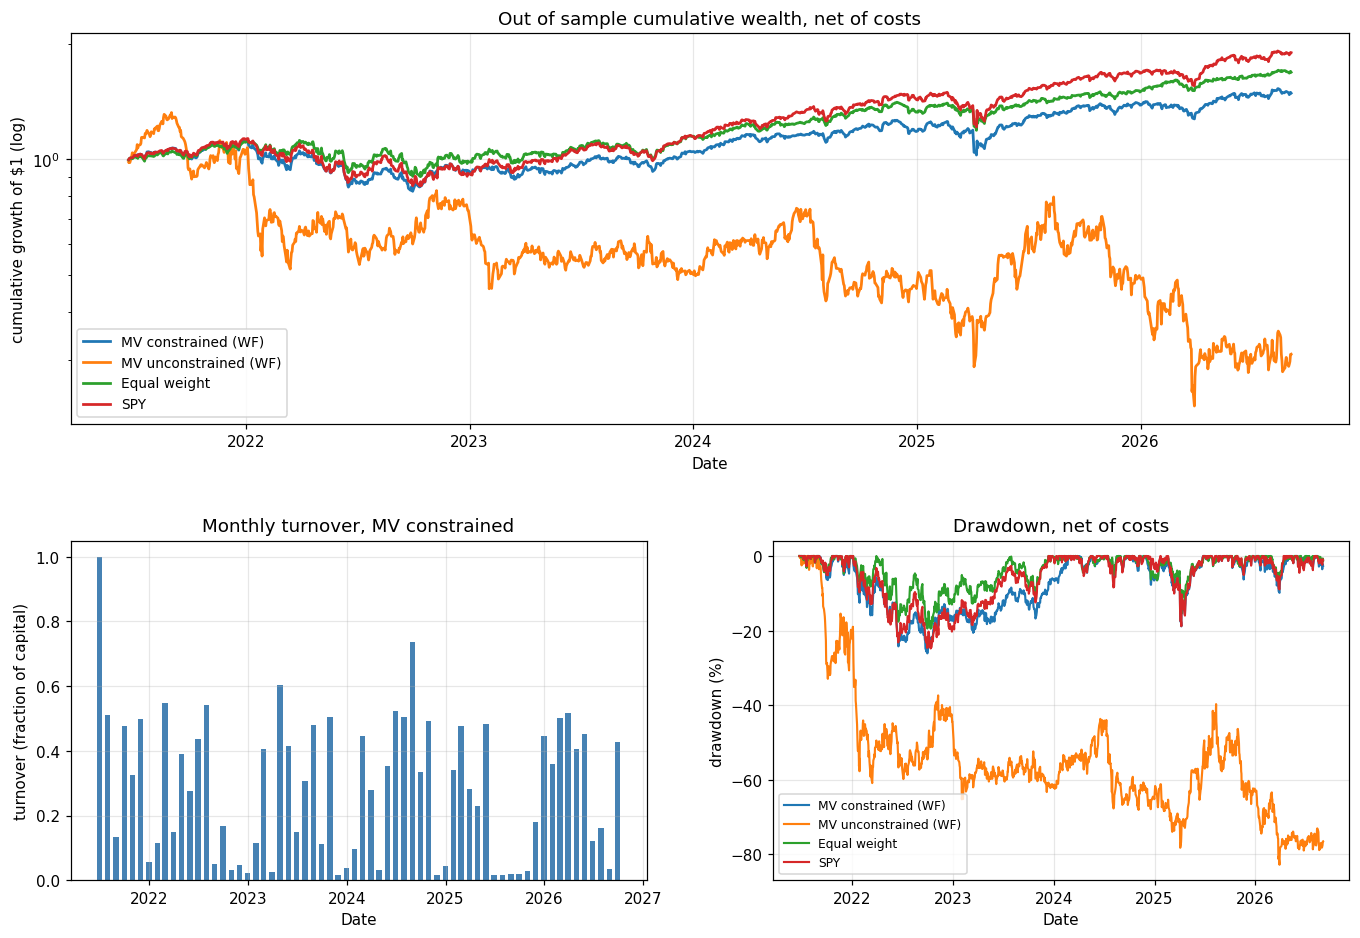

In [38]:
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1.15, 1], hspace=0.32, wspace=0.22)

ax = fig.add_subplot(gs[0, :])
for name in panel.columns:
    ax.plot(panel.index, (1 + panel[name]).cumprod(), lw=1.8, label=name)
ax.set_yscale("log")
ax.set_ylabel("cumulative growth of $1 (log)"); ax.set_xlabel("Date")
ax.set_title("Out of sample cumulative wealth, net of costs")
ax.legend(fontsize=9)

ax = fig.add_subplot(gs[1, 0])
monthly_turn = bt_con["turnover"].resample("ME").sum()
ax.bar(monthly_turn.index, monthly_turn.values, width=20, color="steelblue")
ax.set_xlabel("Date"); ax.set_ylabel("turnover (fraction of capital)")
ax.set_title("Monthly turnover, MV constrained")

ax = fig.add_subplot(gs[1, 1])
for name in panel.columns:
    wealth = (1 + panel[name]).cumprod()
    ax.plot(panel.index, (wealth / wealth.cummax() - 1) * 100, lw=1.4, label=name)
ax.set_xlabel("Date"); ax.set_ylabel("drawdown (%)")
ax.set_title("Drawdown, net of costs"); ax.legend(fontsize=8)
plt.show()

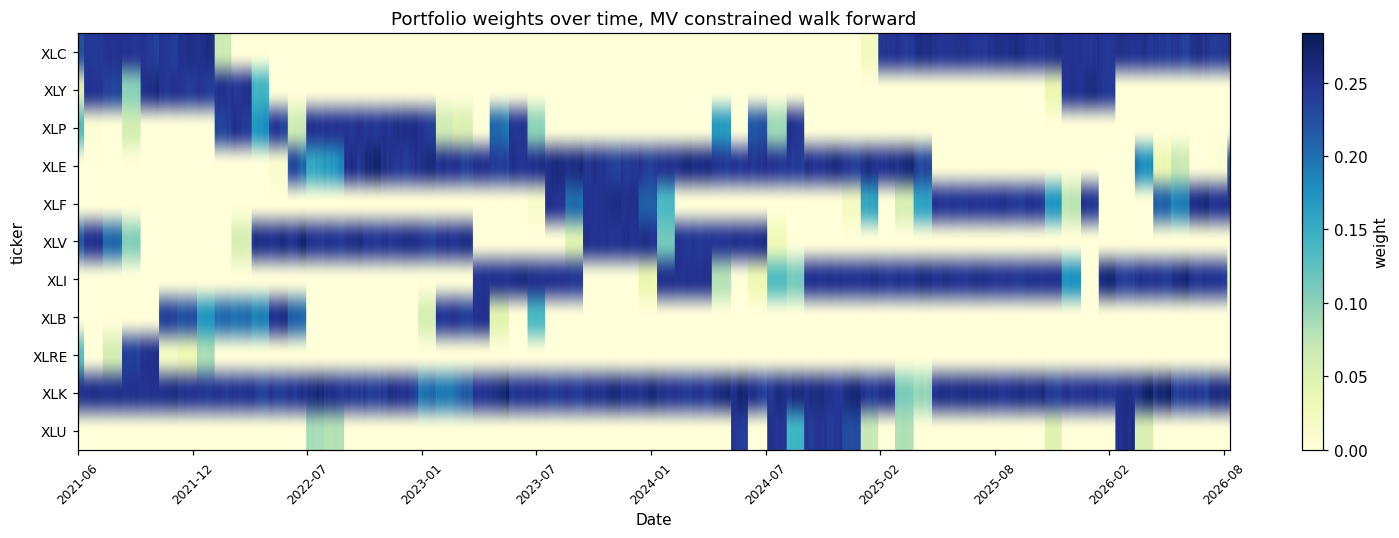

Concentration diagnostics, MV constrained


,mean weight,max weight,% of days held,% of days at cap
XLC,0.107,0.259,45.371,20.964
XLY,0.048,0.263,22.724,8.340
XLP,0.068,0.258,35.960,6.656
XLE,0.142,0.272,62.510,27.161
XLF,0.078,0.266,40.245,11.018
XLV,0.098,0.273,45.601,21.653
XLI,0.129,0.271,57.919,29.074
XLB,0.042,0.256,22.188,3.213
XLRE,0.012,0.255,10.252,1.530
XLK,0.244,0.284,100.000,58.454


Effective number of positions (1 / sum w^2): mean 4.24, min 3.99, max 5.12 (equal weight would be 11)

Holdings on 2021-12-31: XLC 0.253, XLK 0.249, XLY 0.242, XLB 0.225, XLRE 0.032


In [39]:
fig, ax = plt.subplots(figsize=(14, 5))
Wp = wts_con.T
im = ax.imshow(Wp.to_numpy(), aspect="auto", cmap="YlGnBu", vmin=0,
               extent=[0, len(wts_con), K, 0])
ax.set_yticks(np.arange(K) + 0.5); ax.set_yticklabels(ASSETS, fontsize=9)
step = max(len(wts_con) // 10, 1)
ax.set_xticks(np.arange(0, len(wts_con), step))
ax.set_xticklabels([d.strftime("%Y-%m") for d in wts_con.index[::step]],
                   rotation=45, fontsize=8)
ax.set_xlabel("Date"); ax.set_ylabel("ticker")
ax.set_title("Portfolio weights over time, MV constrained walk forward")
ax.grid(False)
fig.colorbar(im, ax=ax, label="weight")
plt.tight_layout(); plt.show()

conc = pd.DataFrame({
    "mean weight":      wts_con.mean(),
    "max weight":       wts_con.max(),
    "% of days held":   (wts_con > 0.01).mean() * 100,
    "% of days at cap": (wts_con > 0.249).mean() * 100,
}).round(3)
print("Concentration diagnostics, MV constrained")
display(conc)

eff_n = 1.0 / (wts_con ** 2).sum(axis=1)
print(f"Effective number of positions (1 / sum w^2): "
      f"mean {eff_n.mean():.2f}, min {eff_n.min():.2f}, max {eff_n.max():.2f} "
      f"(equal weight would be {K})")

snap = wts_con.loc[:"2021-12-31"].iloc[-1]
print(f"\nHoldings on {snap.name.date()}: " +
      ", ".join(f"{t} {w:.3f}" for t, w in snap[snap > 0.005].sort_values(ascending=False).items()))

#### Recommendation

I do not recommend allocating capital to this strategy. Over 5.2 years out of sample it returned 8.94% a year at 16.06% volatility for a Sharpe of 0.557. An equal weight basket of the same eleven sectors earned a Sharpe of 0.766, and simply holding SPY earned 0.812. The strategy also took a deeper drawdown than both, 26.10% against 19.48% for equal weight and 24.79% for SPY. It turned over 3.53x of capital a year to get there and paid 1.832% of capital in costs, against 0.273% for equal weight. Next to the equal weight basket it is supposed to beat, it loses on every line of the tearsheet, and it charges more to lose.

The weight history explains why, and it tells you more than the return series does. The effective number of positions averages 4.24 out of eleven, close to four, the most concentrated book the 25% cap allows. XLK is held on 100% of days and sits at the cap on 58.5% of them. The optimizer isn't diversifying. It is running a concentrated momentum bet on whatever led the trailing three years. At the end of 2021 that meant about three quarters of the book in XLC, XLY and XLK, the three growth heavy sectors, right before 2022.

The unconstrained walk forward version fails in a different way. It lost 68.93% of its capital, with an 82.80% maximum drawdown, 57.20x annual turnover and 29.66% of capital spent on trading costs. That is estimation error, levered up and left alone.

If a version of this gets funded, it needs shrinkage on both inputs before I look at it again, and I would size it as a sleeve next to an allocation that doesn't use μ instead of running it alone. One caveat cuts the other way. This is one realized path over roughly one macro regime, and Section 2.1 showed how wide the sampling distribution of a five year Sharpe is. I am confident the strategy is not better than equal weight. I am not confident about the exact size of the gap.

### 5.3 Interpretation

In [40]:
print("Excess over benchmarks (annualized, net):")
for b in ["Equal weight", "SPY"]:
    d = tear.loc["MV constrained (WF)", "Ann. return"] - tear.loc[b, "Ann. return"]
    print(f"  MV constrained minus {b:<13s}: {d*100:+.2f} pp/yr, "
          f"Sharpe {tear.loc['MV constrained (WF)','Sharpe'] - tear.loc[b,'Sharpe']:+.3f}")

print(f"\nCost drag on the walk forward strategy: "
      f"{bt_con['cost'].sum()*100:.2f}% of capital over {years:.1f} years "
      f"= {bt_con['cost'].sum()/years*100:.2f} pp/yr")

print(f"\nSection 4.1 frictionless static Sharpe (MV constrained): "
      f"{fl_stats.loc['MV constrained','Sharpe']:.3f}")
print(f"Section 5 walk forward net Sharpe   (MV constrained): "
      f"{tear.loc['MV constrained (WF)','Sharpe']:.3f}")

print(f"\nWeight stability: mean absolute month over month weight change = "
      f"{wts_con.resample('ME').last().diff().abs().mean().mean():.4f}")

cal = panel.groupby(panel.index.year).apply(lambda x: (1 + x).prod() - 1)
cal.index.name = "year"
print("\nCalendar year net returns (2021 and 2026 are partial years):")
display((cal * 100).round(2))

Excess over benchmarks (annualized, net):
  MV constrained minus Equal weight : -2.18 pp/yr, Sharpe -0.209
  MV constrained minus SPY          : -4.83 pp/yr, Sharpe -0.255

Cost drag on the walk forward strategy: 1.83% of capital over 5.2 years = 0.35 pp/yr

Section 4.1 frictionless static Sharpe (MV constrained): 1.390
Section 5 walk forward net Sharpe   (MV constrained): 0.557

Weight stability: mean absolute month over month weight change = 0.0255

Calendar year net returns (2021 and 2026 are partial years):


,MV constrained (WF),MV unconstrained (WF),Equal weight,SPY
year,,,,
2021,10.81,3.30,10.92,12.60
2022,-15.72,-28.76,-11.12,-18.58
2023,11.99,-30.89,16.37,25.55
2024,12.98,-9.45,15.75,24.26
2025,17.13,6.96,12.73,17.14
2026,7.44,-36.93,12.62,13.16


#### Against the benchmarks

It loses to both. Constrained mean variance trails equal weight by 2.18 percentage points a year and gives up 0.209 of Sharpe. It trails SPY by 4.83 points a year and 0.255 of Sharpe. It also runs more volatile than equal weight, 16.06% against 14.52%, so it isn't getting paid for extra risk. It takes more risk for less return.

The shortfall comes from concentration driven by an unreliable μ̂. The cap binds at about four effective positions, and the optimizer spends them on whatever led the trailing 756 days. The out of sample period opens in June 2021, when the trailing window covers 2018 to 2021. By December 2021 the book holds XLC, XLY and XLK near the cap. That is the 2022 loss, 15.72% for the strategy against 11.12% for equal weight, and it is the failure Section 2.3 predicted when the rolling estimates moved in regimes.

It didn't lose every year. It lost to equal weight in five of the six calendar years in the sample and won only 2025, 17.13% against 12.73%.

The comparison with equal weight matters more than the one with SPY. Equal weight holds the same eleven assets and estimates nothing. Losing to it isolates the finding. On this universe over this window, the estimates subtracted value.

#### How much of the gap is costs

Very little. Most of the apparent gap has nothing to do with costs.

Cost drag on the walk forward strategy is 1.83% of capital over 5.2 years, or 0.35 percentage points a year. The frictionless static Sharpe in Section 4.1 was 1.390, and the Section 5 walk forward net Sharpe is 0.557. A gap of 0.833 cannot come from 0.35 points a year of friction.

Two things explain most of it. First, the windows differ. Section 4.1 covers May 2023 to September 2026. Section 5 covers June 2021 to September 2026, so it includes 2022, which Section 4.1 skips because 2022 sits inside its training set. That alone should make you distrust a direct Sharpe comparison between the two sections. I only caught it by checking the date ranges. Second, Section 4.1 estimates once and holds, while Section 5 reestimates every month and keeps chasing a noisy, moving μ̂.

So costs are real but second order here. The dominant effects are that constant reestimation on noisy inputs hurt, and that two different evaluation windows were never comparable in the first place.

#### Concentration and stability

Concentration, not diversification, and it was stable in the worst way.

The effective number of positions averages 4.24 and ranges from 3.99 to 5.12, against eleven under equal weight. Under a 25% cap the most concentrated book you can hold is four sectors at the cap, so the strategy sits at that ceiling nearly all the time. XLK is held on 100% of days and at the cap on 58.5% of them. XLE is held on 62.5% of days and XLI on 57.9%. At the other end, XLRE is held on 10.3% of days with a mean weight of 0.012. Weights drift above the cap between monthly rebalances, which is why the max weight column runs as high as 0.284.

Stability tells the same story. The mean absolute month over month weight change is 0.0255, which is small. The book isn't thrashing. But a stable concentrated book is a static bet dressed up as a dynamic strategy, and it means the 3.53x annual turnover buys almost no adaptation. I am paying active trading costs for something close to a fixed four sector tilt.

The constraint does most of the work of making this look sensible. Without it, the walk forward book lost 68.93% of its capital. With it, the optimizer produces something tradeable that is no better than not optimizing at all.

#### What I would change with real money

Four changes, each tied to a finding above.

Shrink μ̂. The bootstrap intervals in 2.3 contain zero for nine of eleven sectors, and 3.2 showed I need 86% shrinkage before the weights fit inside my capital. I would shrink toward the cross sectional average rather than toward zero, which keeps the ranking while pulling in the extremes. Uniform scaling can't do that.

Shrink Σ̂. Section 2.4 showed the smallest eigenvalues are both the least reliably estimated and the most influential on the weights. Ledoit and Wolf shrinkage lifts them off the floor at almost no implementation cost. At k = 11 and n = 756 I am far from the degenerate regime, but the mechanism is the same in kind and only milder in degree.

Keep the constraints and add an explicit turnover penalty. Section 3.5 showed the constrained book gives up in sample utility that Section 2 says was never real, and Sections 4.1 and 5 showed the constraint is what kept the book alive. Section 4.2 showed cost is linear and unforgiving. An L1 penalty on the change in weights between rebalances makes the optimizer price trading costs up front instead of paying them after the fact.

Stop treating one backtest as evidence. Section 2.1 showed that with weights held fixed and a perfect model, the estimated Sharpe from one year of data has a standard deviation of 0.985 around a true value of 0.755. One realized five year path is a single draw from a wide distribution. Before allocating I want sensitivity to γ, to window length and to the rebalancing calendar, plus a block bootstrap of the return path to put an interval around the reported Sharpe instead of a point estimate.

## Section 6. Minimum Variance and Risk Parity

I add both alternatives that ignore μ, because together they test the central claim of Section 2.

Minimum variance sets w proportional to the inverse of Σ applied to a vector of ones. It still inverts the covariance matrix but never touches the mean. I run it without constraints, so it can short. Simple risk parity sets wᵢ proportional to 1/σᵢ and uses only the diagonal. No inversion, no off diagonal terms, no mean. That gives a ladder of falling dependence on estimates. Mean variance uses μ̂ and all of Σ̂. Minimum variance uses all of Σ̂. Risk parity uses only σ̂.

If Section 2 is right that μ̂ is the noisiest input, the strategies that use less of it should hold up out of sample better than their in sample utility suggests, and they may beat mean variance outright.

In [41]:
bt_mv, wts_mv = run_walkforward("minvar")
bt_rp, wts_rp = run_walkforward("riskparity")

panel6 = panel.copy()
panel6["Min variance (WF)"] = bt_mv["net_return"]
panel6["Risk parity (WF)"]  = bt_rp["net_return"]

turn_map6 = dict(turn_map, **{"Min variance (WF)": bt_mv, "Risk parity (WF)": bt_rp})
tear6 = pd.DataFrame({n: perf_stats(panel6[n]) for n in panel6}).T
tear6["Ann. turnover"]      = [turn_map6[n]["turnover"].sum() / years for n in tear6.index]
tear6["Total cost (% cap)"] = [turn_map6[n]["cost"].sum() * 100 for n in tear6.index]
print("All strategies, identical out of sample window, net of costs")
tear6.round(4)

        minvar: 1307 out of sample days, 2021-06-23 -> 2026-09-04, 64 rebalances


    riskparity: 1307 out of sample days, 2021-06-23 -> 2026-09-04, 64 rebalances
All strategies, identical out of sample window, net of costs


,Ann. return,Ann. volatility,Sharpe,Max drawdown,Cumulative return,Ann. turnover,Total cost (% cap)
MV constrained (WF),0.0894,0.1606,0.5568,-0.2610,0.4871,3.5313,1.8315
MV unconstrained (WF),-0.0493,0.5907,-0.0834,-0.8280,-0.6893,57.1951,29.6643
Equal weight,0.1113,0.1452,0.7661,-0.1948,0.6859,0.5257,0.2727
SPY,0.1377,0.1695,0.8122,-0.2479,0.8959,0.1928,0.1000
Min variance (WF),0.0563,0.1245,0.4522,-0.1780,0.2861,2.5785,1.3374
Risk parity (WF),0.1016,0.1413,0.7185,-0.2050,0.6078,0.5187,0.2690


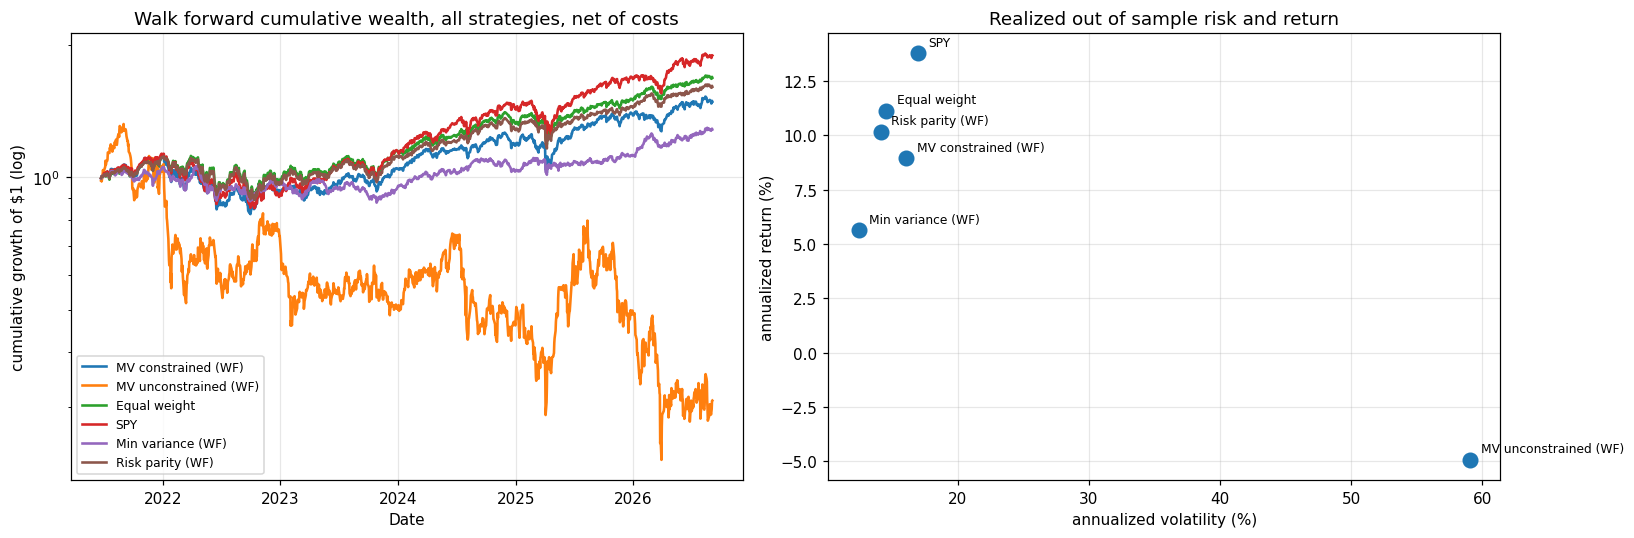

In sample utility (full sample, gamma = 3.0) vs out of sample Sharpe


,in sample utility,OOS net Sharpe
MV constrained,0.1106,0.5568
Min variance,0.0755,0.4522
Risk parity,0.0858,0.7185


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for name in panel6.columns:
    ax.plot(panel6.index, (1 + panel6[name]).cumprod(), lw=1.7, label=name)
ax.set_yscale("log")
ax.set_xlabel("Date"); ax.set_ylabel("cumulative growth of $1 (log)")
ax.set_title("Walk forward cumulative wealth, all strategies, net of costs")
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(tear6["Ann. volatility"] * 100, tear6["Ann. return"] * 100, s=90, zorder=3)
for name, row in tear6.iterrows():
    ax.annotate(name, (row["Ann. volatility"] * 100, row["Ann. return"] * 100),
                textcoords="offset points", xytext=(7, 5), fontsize=8)
ax.set_xlabel("annualized volatility (%)"); ax.set_ylabel("annualized return (%)")
ax.set_title("Realized out of sample risk and return")
plt.tight_layout(); plt.show()

print("In sample utility (full sample, gamma = {:.1f}) vs out of sample Sharpe".format(GAMMA))
W_MV_full  = pd.Series(np.linalg.pinv(SIGMA_SAMPLE.to_numpy()) @ np.ones(K), index=ASSETS)
W_MV_full /= W_MV_full.sum()
iv = 1.0 / np.sqrt(np.diag(SIGMA_SAMPLE.to_numpy()))
W_RP_full = pd.Series(iv / iv.sum(), index=ASSETS)
cmpr = pd.DataFrame({
    "in sample utility": [mv_utility(W_CON, MU_SAMPLE, SIGMA_SAMPLE, GAMMA),
                          mv_utility(W_MV_full, MU_SAMPLE, SIGMA_SAMPLE, GAMMA),
                          mv_utility(W_RP_full, MU_SAMPLE, SIGMA_SAMPLE, GAMMA)],
    "OOS net Sharpe": [tear6.loc["MV constrained (WF)", "Sharpe"],
                       tear6.loc["Min variance (WF)", "Sharpe"],
                       tear6.loc["Risk parity (WF)", "Sharpe"]],
}, index=["MV constrained", "Min variance", "Risk parity"])
display(cmpr.round(4))

#### Interpretation

The comparison table at the bottom is the point of this section, and it doesn't order the way the objective says it should.

In sample, at γ = 3 on the full sample, mean variance wins by construction with utility 0.1106, then risk parity at 0.0858, then minimum variance at 0.0755. Mean variance is the strategy that maximizes that objective, so it cannot lose there.

Out of sample the order partly flips. Risk parity delivers a Sharpe of 0.719 against 0.557 for mean variance, despite giving up 22% of the in sample utility. It also earns more, 10.16% a year against 8.94%, at lower volatility, 14.13% against 16.06%, with a shallower drawdown, 20.50% against 26.10%. The strategy that estimates almost nothing beat the one that estimates everything on every metric, over the same 1,307 days.

That confirms the Section 2 thesis about as directly as a backtest can.

Minimum variance is the exception, and I won't overclaim on it. It comes last on Sharpe at 0.452, earning 5.63% a year. It does deliver the lowest volatility of any strategy here at 12.45% and the smallest drawdown at 17.80%, which is what it is built to do. But it turns over 2.58x a year, second only to constrained mean variance among the sensible strategies, and pays 1.337% of capital in costs against 0.269% for risk parity. Its average weights carry shorts in XLK, XLF, XLRE and XLB. That fits the ladder rather than breaking it. Minimum variance inverts the full Σ̂, the exact operation 2.4 showed amplifies error in the least reliable directions, and that instability shows up as turnover and short positions. Risk parity skips the inversion and turns over 0.52x. Dropping μ̂ helps. Dropping the matrix inverse helps more.

The table says one more thing, and it cuts against all three. Equal weight, which estimates nothing at all, posts a 0.766 Sharpe and beats every optimized strategy in the notebook. Risk parity comes closest at 0.719.

The caveat from 5.3 applies in full. This is one path over roughly one macro regime, and Section 2.1 showed how wide the sampling distribution of a realized Sharpe is. The conclusion is directional, not definitive. It is evidence about which inputs are worth estimating, not a permanent ranking of strategies.